# **Predicting Term Deposits Subscription: A Classification & Segmentation Approach for Bank Telemarketing Campaigns**

## **01. Data Cleaning & EDA**

# Problem Statement:

A bank conducted a telemarketing campaign for one of its financial products called ‘Term Deposits’ to help foster long-term relationships with existing customers. The dataset contains information about all the customers who were contacted during a particular year to open term deposit accounts with the bank.

What is the term Deposit?

Term deposits also called fixed deposits, are the cash investments made for a specific time period ranging from 1 month to 5 years for predetermined fixed interest rates. The fixed interest rates offered for term deposits are higher than the regular interest rates for savings accounts. The customers receive the total amount (investment plus the interest) at the end of the maturity period. Also, the money can only be withdrawn at the end of the maturity period. Withdrawing money before that will result in an added penalty associated, and the customer will not receive any interest returns.


# Business Objective:

**This project implements the machine learning binary classification to predict if the customer will take/** **subscribe a bank term deposit (variable y) by analyzing various customers dimensions. Build a model for Data-Driven Approach to Predict the Success of Bank Telemarketing**


### **1. Data Ingestion & Understanding**

In [175]:
# Import Libraries

import pandas as pd 
import numpy as np  
import sidetable
import sklearn
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from glob import glob
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from itertools import combinations

In [271]:
# Display Settings

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
import warnings
warnings.filterwarnings('ignore')

from IPython.display import display
from IPython.display import Markdown

# Display markdown formatted output like bold, italic bold etc.'''
def display_md(string):
    display(Markdown(string))
    

### **1.1. Data Ingestion & Basic Understanding**

In [ ]:
path = Path.cwd().parent
path_data = path/'data'/'raw'
files = []
for file in path_data.glob('*'):
    files.append(file)

files 

[WindowsPath('e:/Bank-Telemarketing/data/raw/.gitkeep'),
 WindowsPath('e:/Bank-Telemarketing/data/raw/bank-additional-full.csv'),
 WindowsPath('e:/Bank-Telemarketing/data/raw/bank-additional-names.txt'),
 WindowsPath('e:/Bank-Telemarketing/data/raw/bank-full.csv'),
 WindowsPath('e:/Bank-Telemarketing/data/raw/info.txt')]

In [178]:
f = open(path_data/'bank-additional-names.txt','rt')
for line in f.readlines():
    print(line.strip())

Citation Request:
This dataset is publicly available for research. The details are described in [Moro et al., 2014].
Please include this citation if you plan to use this database:

[Moro et al., 2014] S. Moro, P. Cortez and P. Rita. A Data-Driven Approach to Predict the Success of Bank Telemarketing. Decision Support Systems, In press, http://dx.doi.org/10.1016/j.dss.2014.03.001

Available at: [pdf] http://dx.doi.org/10.1016/j.dss.2014.03.001
[bib] http://www3.dsi.uminho.pt/pcortez/bib/2014-dss.txt

1. Title: Bank Marketing (with social/economic context)

2. Sources
Created by: Sérgio Moro (ISCTE-IUL), Paulo Cortez (Univ. Minho) and Paulo Rita (ISCTE-IUL) @ 2014

3. Past Usage:

The full dataset (bank-additional-full.csv) was described and analyzed in:

S. Moro, P. Cortez and P. Rita. A Data-Driven Approach to Predict the Success of Bank Telemarketing. Decision Support Systems (2014), doi:10.1016/j.dss.2014.03.001.

4. Relevant Information:

This dataset is based on "Bank Marketing" UC

In [228]:
print("Loading raw data...")
try:
    org_data = pd.read_csv(path/'data'/'raw'/'bank-full.csv', sep=';')
    org_data.columns = org_data.columns.str.strip().str.replace(".", "_").str.replace(" ", "_")
    display(org_data.head(2))
    print(f"Duplicate Entries : {org_data.duplicated().sum()}", end="\n\n")
    print(f"Dataset Shape : {org_data.shape}")
except Exception as e:
    print(f"Data Loading Error: {e}")



Loading raw data...


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no


Duplicate Entries : 0

Dataset Shape : (45211, 17)


In [229]:
org_data.shape
print('Number of rows:', org_data.shape[0])
print('Number of columns:', org_data.shape[1])

Number of rows: 45211
Number of columns: 17


In [230]:
org_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


The data is collected by Banco de Portugal via direct phone call marketing campaigns but duration of call is not included, where 15 columns are recorded for 45211 term deposit market campaign.

**Bank Client Data Description:**

- **age**: Age of the client (numeric)
- **job**: Type of job (categorical: 'admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired', 'self-employed', 'services', 'student', 'technician', 'unemployed', 'unknown')
- **marital**: Marital status (categorical: 'divorced', 'married', 'single')
- **education**: Level of education (categorical: 'secondary', 'tertiary', 'primary', 'unknown')
- **default**: Whether the client has credit in default (binary: 'no', 'yes')
- **housing**: Whether the client has a housing loan (binary: 'no', 'yes')
- **loan**: Whether the client has a personal loan (binary: 'no', 'yes')

**Last Contact Data Description:**

- **contact**: Type of communication used to contact the client (categorical: 'cellular', 'telephone', 'unknown')
- **month**: Last contact month of the year (categorical: 'jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec')
- **day**: Last contact day of the month (numerical)
- **duration**: Duration of the last contact in seconds (numeric)
Important note:  this attribute highly affects the output target (e.g., if duration=0 then y="no"). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model

**Campaign Data Description:**

- **campaign**: Number of contacts performed during this campaign for this client (numeric, includes last contact)
- **pdays**: Number of days since the client was last contacted from a previous campaign (numeric; -1 means client was not previously contacted)
- **previous**: Number of contacts performed before this campaign for this client (numeric) 
- **poutcome**: Outcome of the previous marketing campaign (categorical: 'failure', 'unknown', 'success')

**Target Variable:**
- **y**: Whether the client subscribed to a term deposit (binary: 'no', 'yes')



***Dataset Summary:***

**This dataset represents the direct marketing campaign(phone calls) of a Portuguese banking institution, where each record represents a client and the outcome of a marketing campaign to convince the client to subscribe a term deposit. The dataset contains both categorical and numerical features describing each client's demographics, behaviroal, social and economic context, with a binary target variable indicating whether the client subscribed to a term deposit. The data spans from May 2008 to November 2010**

**Missing Attribute Values**: There are several missing values in some categorical attributes, all coded with the "unknown" label. These missing values can be treated as a possible class label or using deletion or imputation techniques.


### **2. Formatting and Consistency Checks**

In [231]:
pd.DataFrame({
    'dtype':org_data.dtypes,
    'nunique': org_data.nunique(),
    'unique': [org_data[col].unique() for col in org_data.columns]},
    index=org_data.columns)

,dtype,nunique,unique
age,int64,77,"[58, 44, 33, 47, 35, 28, 42, 43, 41, 29, 53, 5..."
job,object,12,"[management, technician, entrepreneur, blue-co..."
marital,object,3,"[married, single, divorced]"
education,object,4,"[tertiary, secondary, unknown, primary]"
default,object,2,"[no, yes]"
balance,int64,7168,"[2143, 29, 2, 1506, 1, 231, 447, 121, 593, 270..."
housing,object,2,"[yes, no]"
loan,object,2,"[no, yes]"
contact,object,3,"[unknown, cellular, telephone]"
day,int64,31,"[5, 6, 7, 8, 9, 12, 13, 14, 15, 16, 19, 20, 21..."


In [232]:
def highlight_zero_negative(val):
    if val < 0:
        return 'background-color: red; color: white;'  # Negative values styled in red
    elif val == 0:
        return 'background-color: yellow; color: black;'  # Zero values styled in yellow
    else:
        return ''  # No styling for positive values

In [233]:
def highlight_repeats(series):
    is_repeat = series.duplicated(keep=False)  # Identify repeated values
    return ['background-color: green; color: white' if repeat else '' for repeat in is_repeat]


In [234]:
# Formatting and data descripition for numerical columns 
df_descb = org_data.describe(include='number')
print("Zero & Negative Values in Dataset :")
display(df_descb.style.applymap(highlight_zero_negative))

print("Repeat Values in Dataset :", end="\n\n")
display(df_descb.style.apply(highlight_repeats))

Zero & Negative Values in Dataset :


,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


Repeat Values in Dataset :



,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [235]:
org_data[org_data['duration'].isin([0])]['y']

6424     no
22937    no
36425    no
Name: y, dtype: object

In [236]:
org_data.stb.missing().query("percent > 0")

,missing,total,percent


In [237]:
org_data.describe(exclude='number')

,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
unique,12,3,4,2,2,2,3,12,4,2
top,blue-collar,married,secondary,no,yes,no,cellular,may,unknown,no
freq,9732,27214,23202,44396,25130,37967,29285,13766,36959,39922


**NOTEs:**

- **Duration**: this attribute highly affects the output target (e.g., if duration=0 then y="no"). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.

- **pdays** : -1 means client was not previously contacted

- As there are no `NaN` values in the dataset, we will focus on the numerical features during preprocessing.


## **3. EDA**

In [240]:
data = org_data.copy()

In [241]:
# Categorical columns Consistency Check

def calculate_category_cols_info(df:pd.DataFrame):
    #Store data in dictionary
    value_dict = {}
    pct_dict = {}

    # Get categorical columns
    cat_cols = df.select_dtypes(include=['object']).columns

    # Iterate through each categorical column
    for col in cat_cols:
        count = df[col].value_counts()
        pct = df[col].value_counts(normalize=True) * 100
        value_dict[col] = count.to_dict()
        pct_dict[col] = pct.to_dict()

    # Convert dictionary of dictionaries to DataFrames
    count_df = pd.DataFrame.from_dict(value_dict, orient='index').stack().reset_index()
    count_df.columns = ['Features', 'Category', 'Count']
    pct_df = pd.DataFrame.from_dict(pct_dict, orient='index').stack().reset_index()
    pct_df.columns = ['Features', 'Category', 'Percentage']

    # Merge the two DataFrames on Features and Category
    result_df = pd.merge(count_df, pct_df, on=['Features', 'Category'])
    
    # Set MultiIndex for better readability
    result_df.set_index(['Features', 'Category'], inplace=True)

    return result_df

In [242]:
# Define a function to highlight specific category
def highlight_category(val):
    return np.where(val=='unknown','background-color: orange; color:white;',"")  # Highlight 'unknown' in orange


In [243]:
cat_df = calculate_category_cols_info(data)
cat_df.style.apply_index(highlight_category)

- **Features such as `job, education, contact, and poutcome` contain 'unknown' values. We will examine how to handle these values during preprocessing.**


#### **3.1. Univariate Analysis of Target Variable**

In [244]:
# Change name of target column(y)
data.rename(columns={'y': 'term_deposit'},inplace=True)

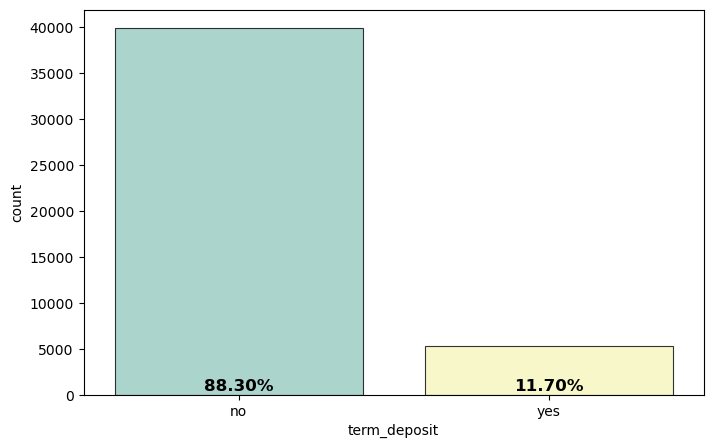

In [245]:
plt.figure(figsize=(8,5))
sns.countplot(x=data['term_deposit'],palette='Set3',alpha=0.8, edgecolor='black', linewidth=0.8)
for i, v in enumerate(round(data['term_deposit'].value_counts(normalize=True)*100,2)):
    plt.text(i, v+50, f'{v:.2f}%',ha='center', va= 'bottom',fontsize=12,fontweight='bold' ,color='black')
plt.show()

**Data is highly imbalanced, with a significant majority of customers not subscribing to the term deposit. This imbalance will need to be addressed in the modeling phase, possibly through techniques such as resampling or using algorithms that can handle class imbalance effectively.**

#### **3.2. Demographic Features Analysis**

- Demographic factors are statistical characteristics of a populations that helps in analyzing and understanding social, economic and cultural trends. Common demographic factors include **age, gender, income, education level, marital status, occupation, and geographic location**. These factors are often used in market research, public health studies, and social science research to segment populations and identify patterns or trends.

By the above definition of demographic factors, the following featurs can be considered as demographic factors in the datset:
- **age**: indicator of the customer's age group, ehich can influence their financial behaviour and lifestyle choices.'
- **job**: indicate the customer's occupation, which can affect their income and financial decisions.
- **marital**: indicates the customer's marital status, which can influence financial priorities and consumption patterns.
- **education**: indicates the customer's level of education, which can impact their financial literacy and decision-making abilities.

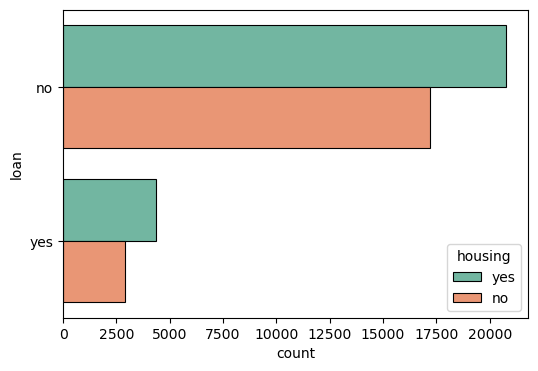

In [195]:
# Number of campaign customer by personal loans and housing loans
plt.figure(figsize=(6,4))
sns.countplot(data=data, y='loan', hue='housing', palette='Set2', edgecolor='black', linewidth=0.8)
plt.show()

In [288]:
# numeric features distribution plots
def univariate_numeric_distribution(df:pd.DataFrame, col:str):
    fig, ax = plt.subplots(ncols=2, figsize=(15, 5))

    sns.histplot(data=df, x = col, ax=ax[0], bins=30, kde=True, stat='density', color='lightskyblue')
    ax[0].lines[0].set_color('crimson')
    ax[0].set_title(f'{col.capitalize()} Distribution with Density Curve', fontsize=14, fontweight='bold')
    
    sns.boxplot(data=df, x = col, ax=ax[1], fill=False, color='k', flierprops=dict(marker='o', markerfacecolor='r'))
    ax[1].set_title(f'Box Plot for {col.capitalize()}', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.3, hspace=0.3)
    plt.show()
    

In [298]:
# categorical features distribution plots
def univariate_categorical_distribution(df: pd.DataFrame, col: str):
    fig, ax = plt.subplots(ncols=2, figsize=(20, 8))

    # Bar plot (frequency counts)
    sns.countplot(data=df, x=col, order=df[col].value_counts().index, ax=ax[0], palette="pastel")
    ax[0].set_title(f'{col.capitalize()} Distribution (Bar Plot)', fontsize=14, fontweight='bold', y=1.02)
    ax[0].tick_params(axis='x', rotation=45)

    # Pie plot (proportions)
    counts = df[col].value_counts()
    ax[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%', startangle=45, colors=sns.color_palette("pastel"), textprops={'fontsize': 12})
    ax[1].axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
    ax[1].set_title(f'{col.capitalize()} Distribution (Pie Chart)', fontsize=14, fontweight='bold', y=1.02)

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.3, hspace=0.3)
    plt.show()


In [196]:
# plots for numeric columns and target column
def plot_numeric_columns(df:pd.DataFrame, column:str, target:str='term_deposit', kde:bool = True,edgecolor:str = 'black',multiple:str ='stack') ->None:
    ''' 
    Plots histogram and normalized histogram of specified numeric columns with a target column in hue.

    Parameters:


    Returns:
    None: Displays the histogram and normalized histogram plots for numeric columns.
    '''
    fig, ax = plt.subplots(ncols=2, figsize=(15,5),sharey=True)

    # histogram plot for each type of term_deposit customer
    sns.histplot(data=df, y=column, hue=target ,kde=kde, edgecolor=edgecolor,linewidth=0.8, legend=False, alpha =0.6,multiple=multiple ,ax=ax[0])

    # Normalized histogram plot for each type of term_deposit customer
    sns.histplot(data=df, y=column, hue=target,kde=kde ,stat='percent', edgecolor=edgecolor,linewidth=0.8, multiple=multiple ,ax=ax[1])

    # set titles and labels
    ax[0].set_ylabel(column.capitalize(), fontsize=12, fontweight='bold')
    ax[0].set_xlabel('Term Deposit Count', fontsize=12, fontweight='bold')
    ax[1].set_xlabel('Term Deposit Percentage', fontsize=12, fontweight='bold')

    # Hide all spines for both subplots
    sns.despine(left=True,bottom=True)
    # Display settings
    plt.suptitle(f'Distribution of Counts & Percentages of Normalized Term Deposit for {column.capitalize()}', fontsize=14, fontweight='bold')
    plt.subplots_adjust(top=0.96)
    plt.tight_layout()
    plt.show()


In [197]:
# plots for categorical columns and target column
def plot_categorical_columns(df:pd.DataFrame, column: str, target:str='term_deposit'):
    """
    Plot counts and percentages of a categorical column with respect to a target column.

    Parameters:

    Returns:
    None: Displays the bar plot of counts and percentages of the categorical column with respect to the target column.
    """
    # count DataFrame for the specified column and target
    count_df = pd.crosstab(df[column], df[target]).stack().reset_index().rename(columns={0:'count'})
                                                                                
    # percentage DataFrame for the specified column and target
    pct_df = (pd.crosstab(df[column], df[target], normalize='index').round(4)*100).stack().reset_index().rename(columns={0:'percentage'})

    # Display the counts DataFrame
    display(count_df.head(10))

    # Create subplots for count and percentage
    fig, ax = plt.subplots(ncols=2, figsize=(15, 5), sharey=True)

    #plot using seaborn barplot for count and percentage
    sns.barplot(data=count_df, x='count', y=column, hue=target, ax=ax[0], palette='Set2', edgecolor='black', linewidth=0.8)
    sns.barplot(data=pct_df, x='percentage', y=column, hue=target, ax=ax[1], palette='Set2', edgecolor='black', linewidth=0.8,legend=False)

    # Set titles and labels
    ax[0].set_ylabel(column.capitalize(), fontsize=12, fontweight='bold')
    ax[0].set_xlabel('Count', fontsize=12, fontweight='bold')
    ax[1].set_xlabel('Percentage', fontsize=12, fontweight='bold')
    

    # Hide all spines for both subplots
    sns.despine(left=True, bottom=True)
    
    # Display settings
    plt.suptitle(f'Counts & Percentages of Term Deposit for each category in {column.capitalize()}', fontsize=14, fontweight='bold')
    plt.subplots_adjust(top=0.96)   
    plt.tight_layout()

    #add legend to the first subplot
    ax[0].legend(labelcolor='linecolor', loc='lower right', title=target.capitalize(),edgecolor='black', fontsize=10, title_fontsize='12', frameon=True, framealpha=0.8)
    plt.show()

                                                                                                                                        

**Age**

In [253]:
print("Age Distribution Summary:")
print(data['age'].describe())


Age Distribution Summary:
count   45211.00
mean       40.94
std        10.62
min        18.00
25%        33.00
50%        39.00
75%        48.00
max        95.00
Name: age, dtype: float64


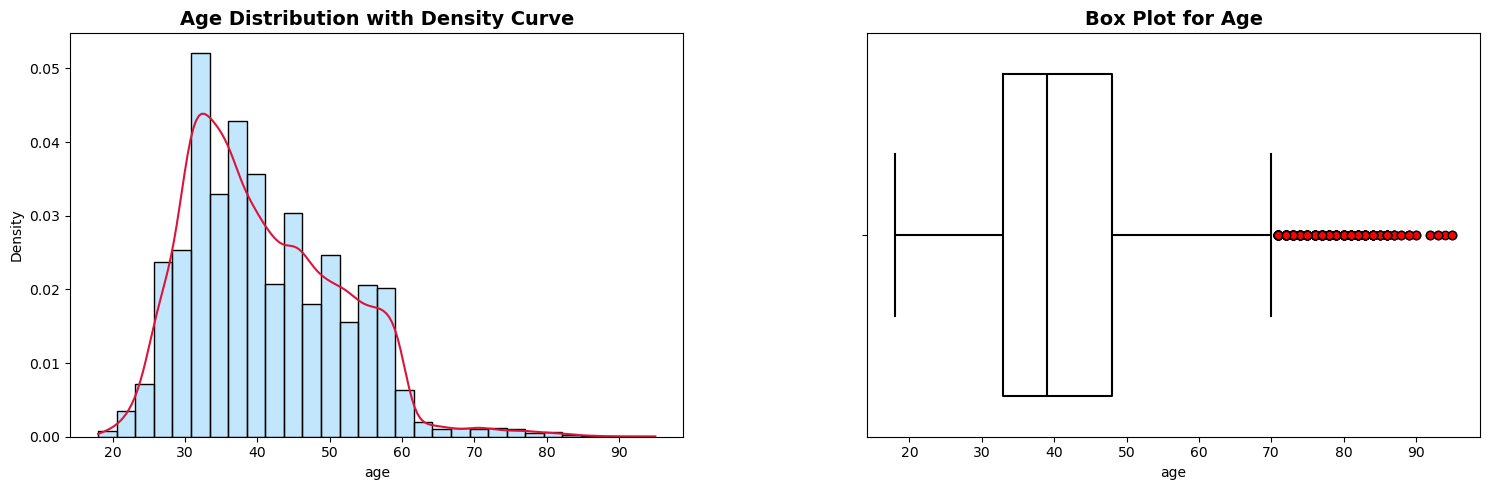

In [290]:
univariate_numeric_distribution(data, 'age')

In [278]:
# Create age groups
def categorize_age(age):
    if age < 25:
        return 'Young (18-24)'
    elif age < 35:
        return 'Young Adult (25-34)'
    elif age < 50:
        return 'Middle Age (35-49)'
    elif age < 65:
        return 'Senior (50-64)'
    else:
        return 'Super Senior (65+)'

data['age_group'] = data['age'].apply(categorize_age)

# Count and percentage by age group
age_group_counts = data['age_group'].value_counts()
age_group_percentages = data['age_group'].value_counts(normalize=True) * 100

display_md("**Age Group Distribution:**")
for group in age_group_counts.index:
    display(f"{group} : {age_group_counts[group]} ({age_group_percentages[group]:.2f}%)")


**Age Group Distribution:**

'Middle Age (35-49) : 20004 (44.25%)'

'Young Adult (25-34) : 14204 (31.42%)'

'Senior (50-64) : 9384 (20.76%)'

'Super Senior (65+) : 810 (1.79%)'

'Young (18-24) : 809 (1.79%)'

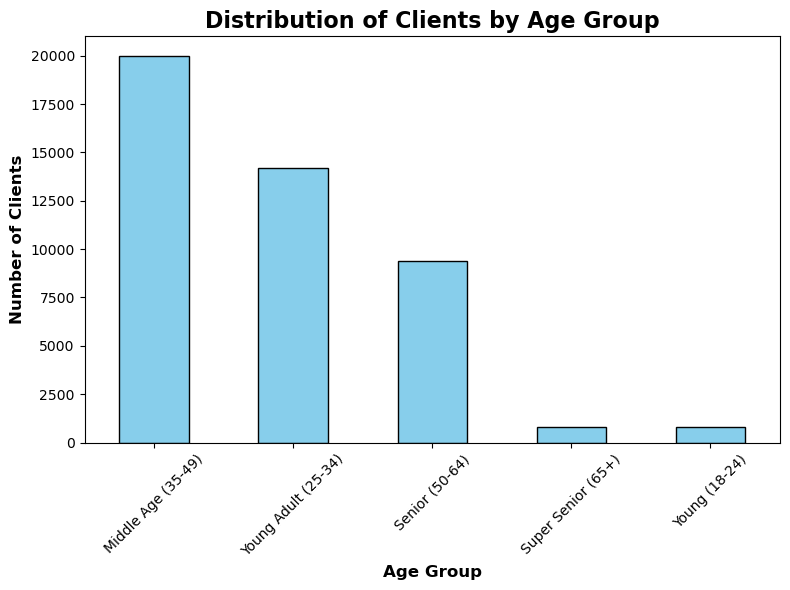

In [279]:
plt.figure(figsize=(8, 6))
age_group_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of Clients by Age Group', fontsize=16, fontweight='bold')
plt.xlabel('Age Group', fontsize=12, fontweight='bold')
plt.ylabel('Number of Clients', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

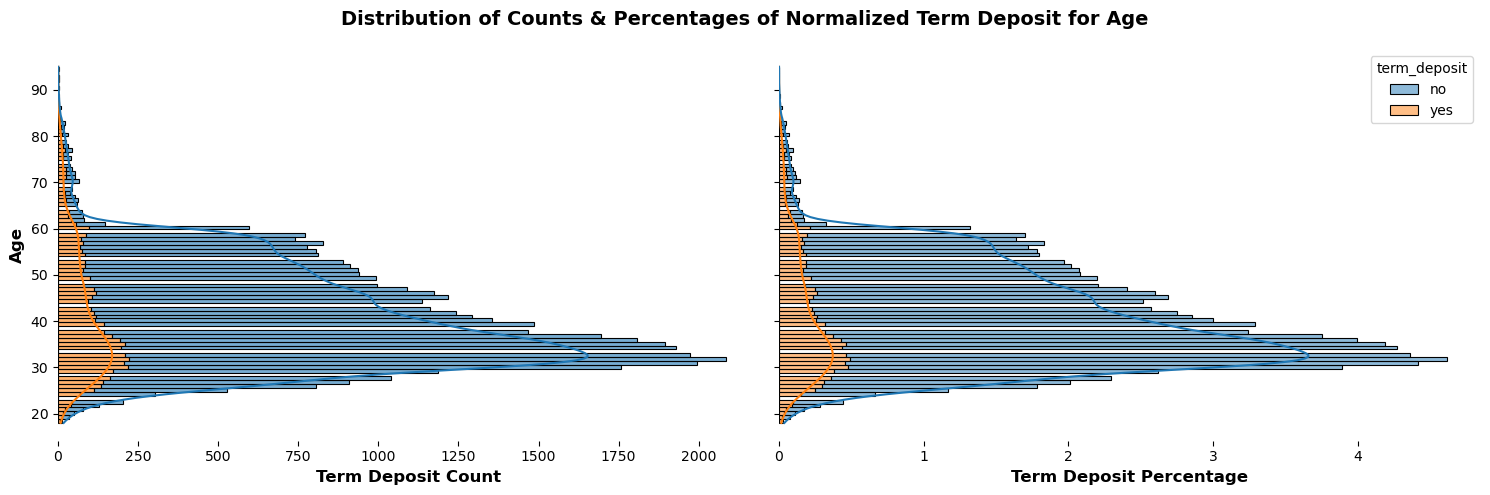

In [199]:
plot_numeric_columns(data, 'age')

**job**

In [274]:
display_md("**Job type summary :**")
display(data['job'].value_counts())

**Job type summary :**

job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

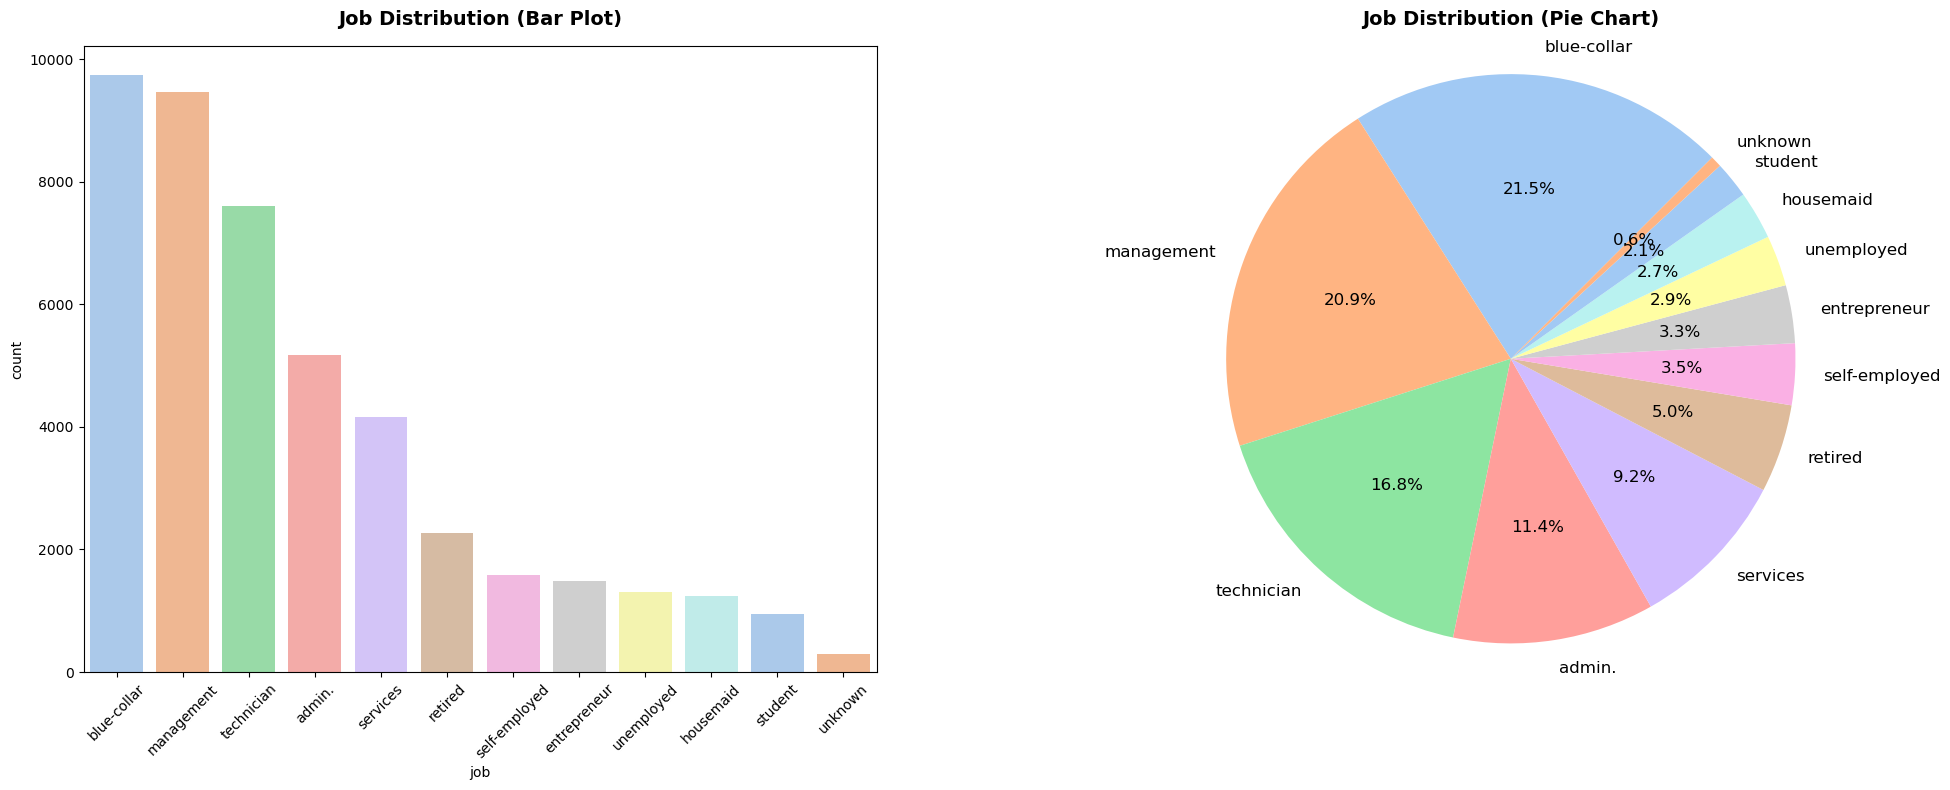

In [299]:
univariate_categorical_distribution(data, 'job')


In [301]:
# Average age by job type
job_age_stats = data.groupby('job')['age'].agg(['mean', 'median', 'std']).round(2)
job_age_stats = job_age_stats.sort_values('mean', ascending=False)

display_md("**Age Statistics by Job Type:**")
display(job_age_stats)

**Age Statistics by Job Type:**

,mean,median,std
job,,,
retired,61.63,59.00,9.54
unknown,47.59,47.00,10.78
housemaid,46.42,47.00,10.48
entrepreneur,42.19,41.00,9.11
unemployed,40.96,40.00,9.78
self-employed,40.48,39.00,9.66
management,40.45,38.00,9.38
blue-collar,40.04,39.00,9.03
technician,39.31,37.00,8.94


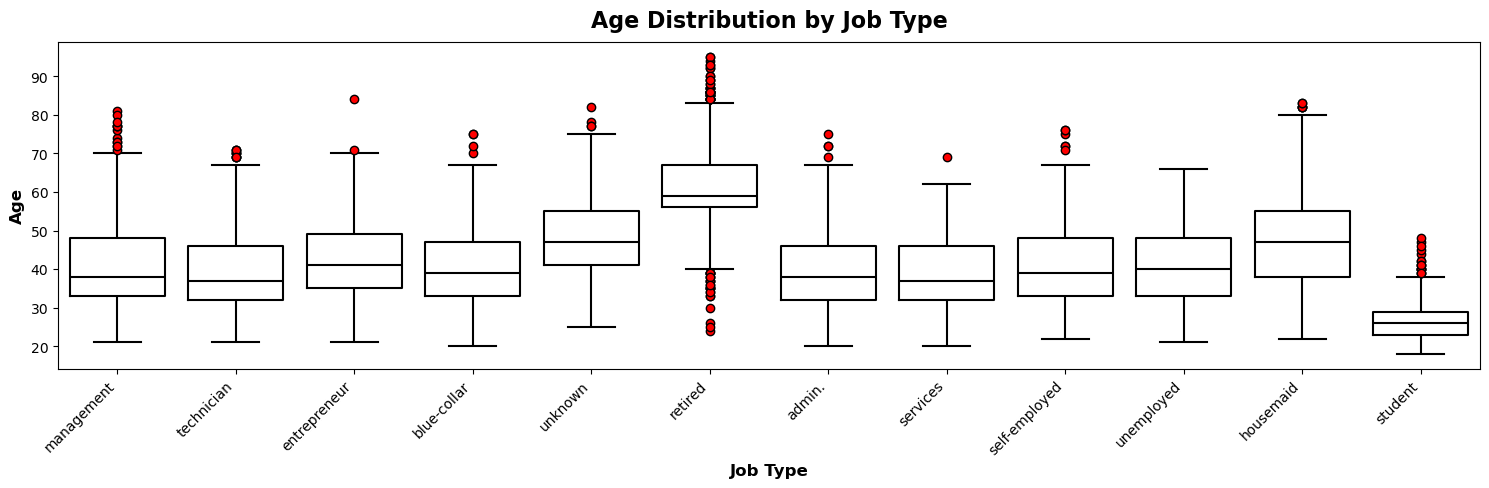

In [304]:
plt.figure(figsize=(15, 5))
sns.boxplot(data, x='job', y='age', fill=False, color='k', flierprops=dict(marker='o', markerfacecolor='r'))
plt.title('Age Distribution by Job Type', fontsize=16, fontweight='bold', y=1.02)
plt.xlabel('Job Type', fontsize=12, fontweight='bold')
plt.ylabel('Age', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [305]:
print("Job Type Summary:")
print(f"Total unique job types: {data['job'].nunique()}")
print(f"Most common job: {data['job'].mode()[0]} ({data['job'].value_counts().iloc[0]} clients)")
print(f"Least common job: {data['job'].value_counts().index[-1]} ({data['job'].value_counts().iloc[-1]} clients)")

Job Type Summary:
Total unique job types: 12
Most common job: blue-collar (9732 clients)
Least common job: unknown (288 clients)


,job,term_deposit,count
0,admin.,no,4540
1,admin.,yes,631
2,blue-collar,no,9024
3,blue-collar,yes,708
4,entrepreneur,no,1364
5,entrepreneur,yes,123
6,housemaid,no,1131
7,housemaid,yes,109
8,management,no,8157
9,management,yes,1301


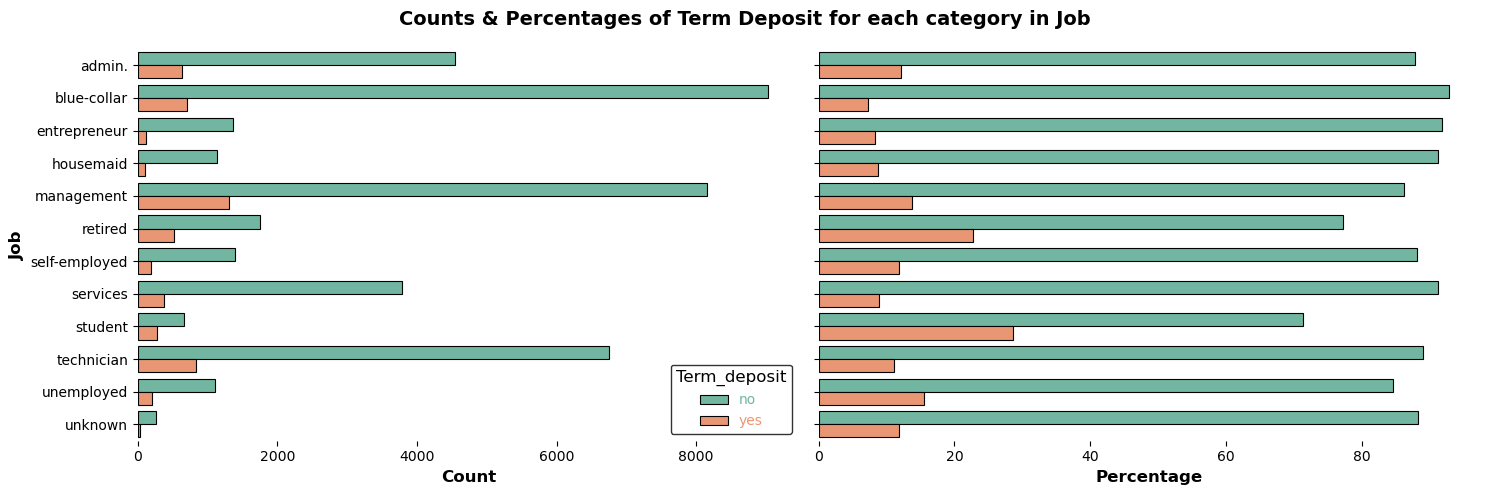

In [201]:
plot_categorical_columns(data, column='job')

**Marital**

In [202]:
data['marital'].value_counts()

marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

,marital,term_deposit,count
0,divorced,no,4585
1,divorced,yes,622
2,married,no,24459
3,married,yes,2755
4,single,no,10878
5,single,yes,1912


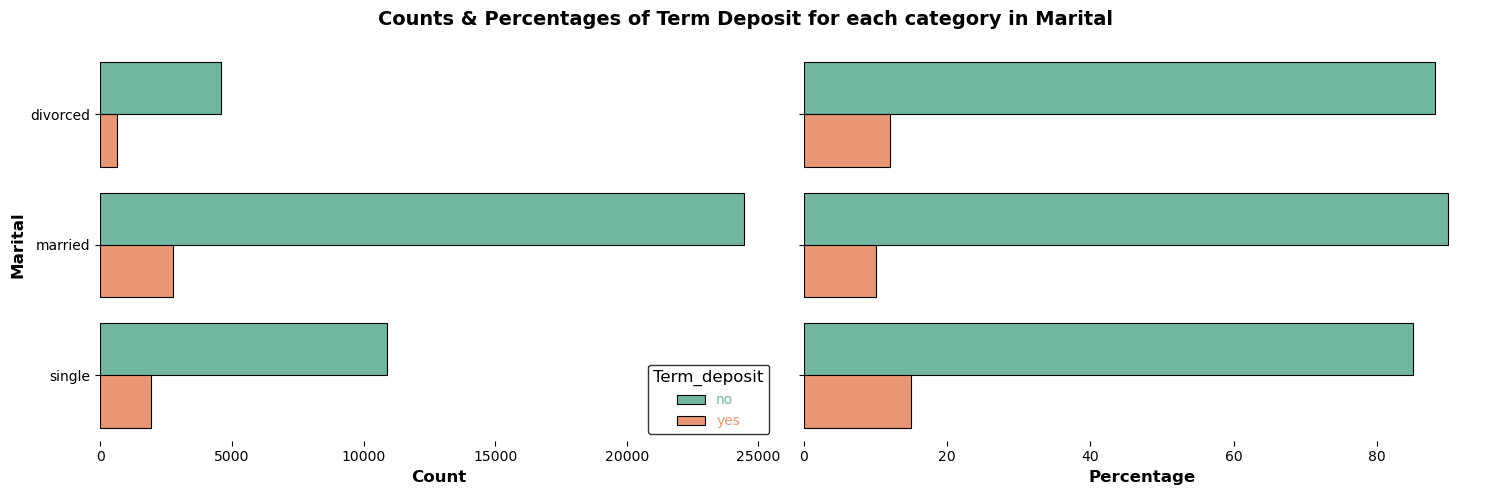

In [203]:
plot_categorical_columns(data, column='marital')

**Education**

In [204]:
data['education'].value_counts()

education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

,education,term_deposit,count
0,primary,no,6260
1,primary,yes,591
2,secondary,no,20752
3,secondary,yes,2450
4,tertiary,no,11305
5,tertiary,yes,1996
6,unknown,no,1605
7,unknown,yes,252


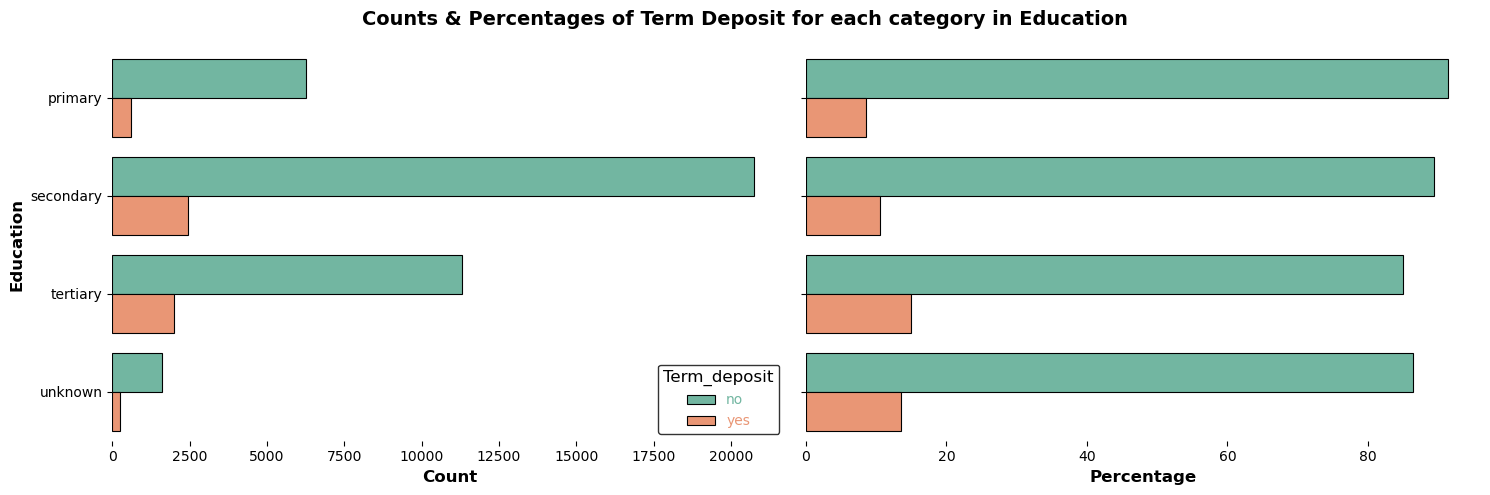

In [205]:
plot_categorical_columns(data, column='education')

### **3.3. Financial/Behavioral Features**

- Those factors which describe how the customer behaves in terms of financial decisions, response to campaigns and interaction with financial products. By this definition following features can be considered as financial factors in the datset:

- **balance**: Average yearly balance in euros.
- **default**: indicates financial relability and risk behaviour.
- **housing**: indicates a whether the customer has long-term financial commitments.
- **loan**: presence of a personal loan indicates borrowing behaviour.
- **campaign**: shows engagement with marketing efforts indicating responsivness.
- **pdays**:  indicates the number of days since the last contact, reflecting the recency of customer interaction.
- **previous**: number of previous contacts, indicating the customer's history with the bank.
- **poutcome**: outcome of the previous marketing campaign, indicating the effectiveness of past interactions.

**Default**

In [206]:
data['default'].value_counts()

default
no     44396
yes      815
Name: count, dtype: int64

,default,term_deposit,count
0,no,no,39159
1,no,yes,5237
2,yes,no,763
3,yes,yes,52


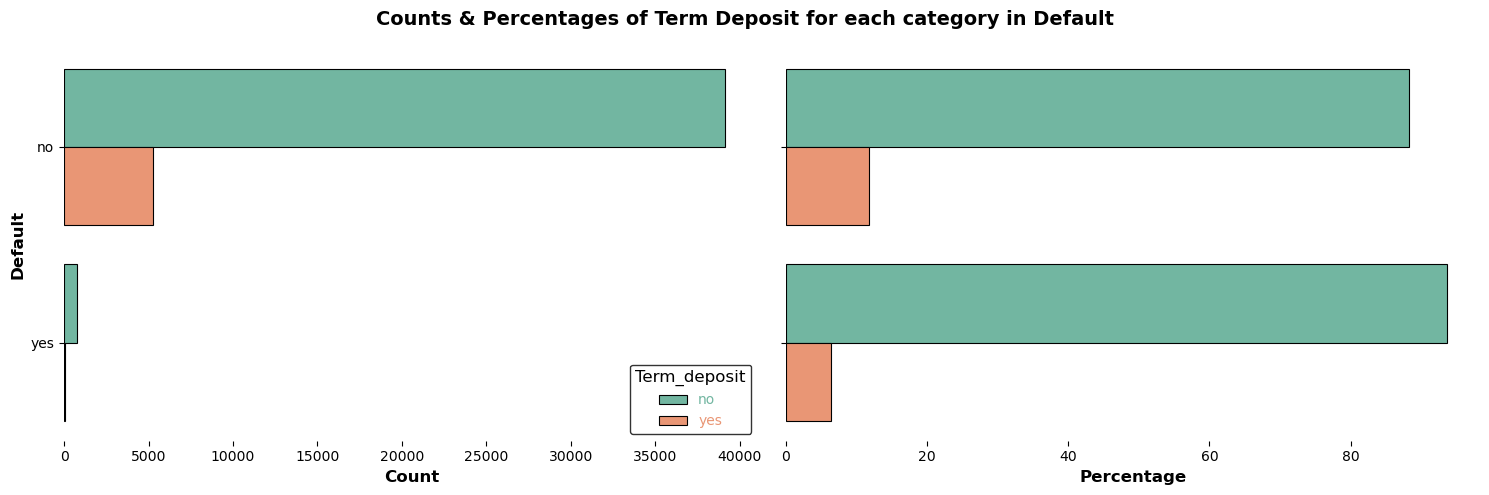

In [207]:
plot_categorical_columns(data, 'default')

default,no,yes
housing,,
no,19701,380
yes,24695,435


<Axes: xlabel='count', ylabel='housing'>

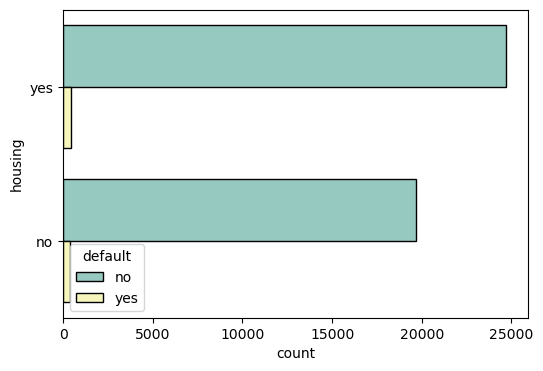

In [208]:
# Number of term_deposit customer by personal loans and housing loans
display(pd.crosstab(data['housing'], data['default']))
plt.figure(figsize=(6,4))
sns.countplot(data=data,y='housing',hue='default',palette='Set3', edgecolor='black')

**Housing**

In [209]:
data['housing'].value_counts()

housing
yes    25130
no     20081
Name: count, dtype: int64

,housing,term_deposit,count
0,no,no,16727
1,no,yes,3354
2,yes,no,23195
3,yes,yes,1935


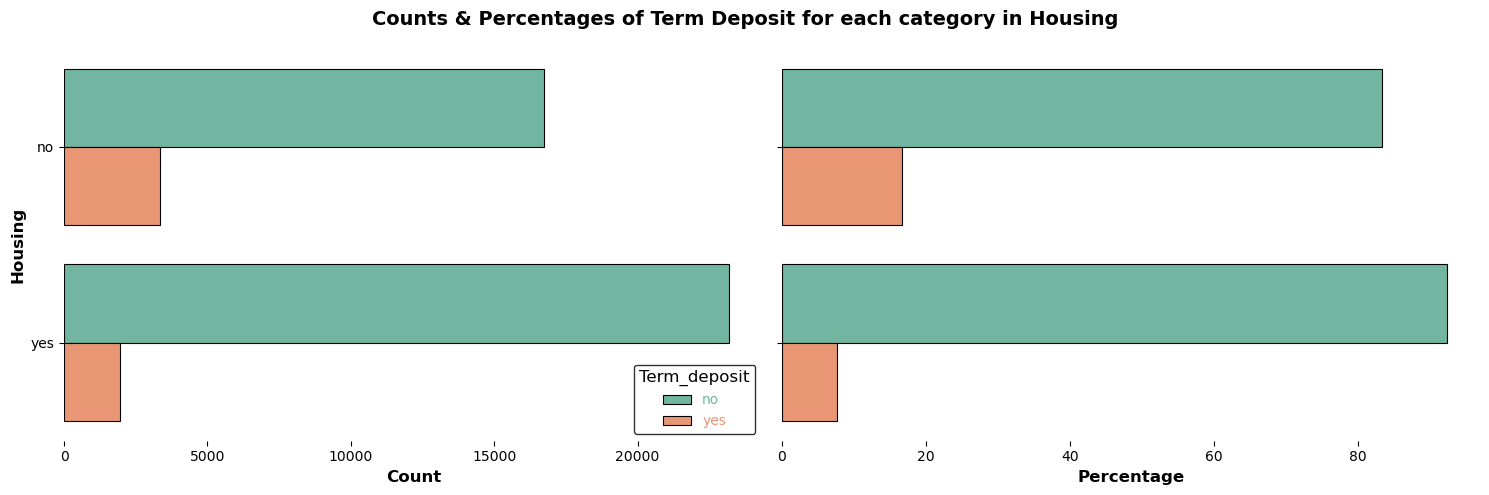

In [210]:
plot_categorical_columns(data, 'housing')

**Poutcome**

In [211]:
data['poutcome'].value_counts()

poutcome
unknown    36959
failure     4901
other       1840
success     1511
Name: count, dtype: int64

,poutcome,term_deposit,count
0,failure,no,4283
1,failure,yes,618
2,other,no,1533
3,other,yes,307
4,success,no,533
5,success,yes,978
6,unknown,no,33573
7,unknown,yes,3386


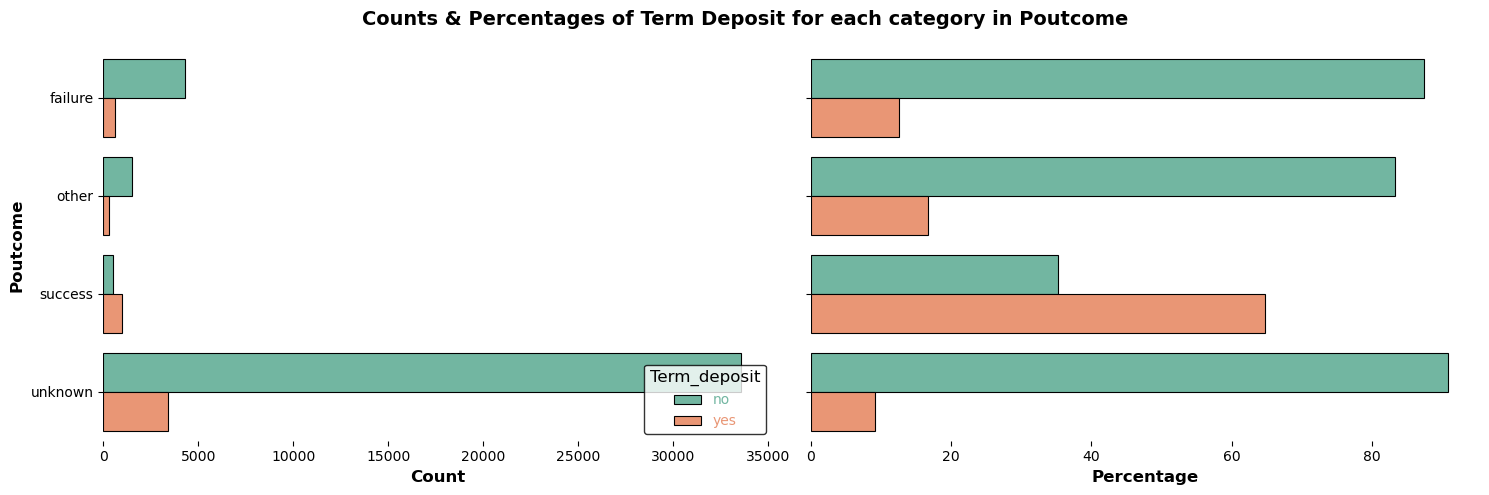

In [212]:
plot_categorical_columns(data,column='poutcome')

**Loan**

In [213]:
data['loan'].value_counts()

loan
no     37967
yes     7244
Name: count, dtype: int64

,loan,term_deposit,count
0,no,no,33162
1,no,yes,4805
2,yes,no,6760
3,yes,yes,484


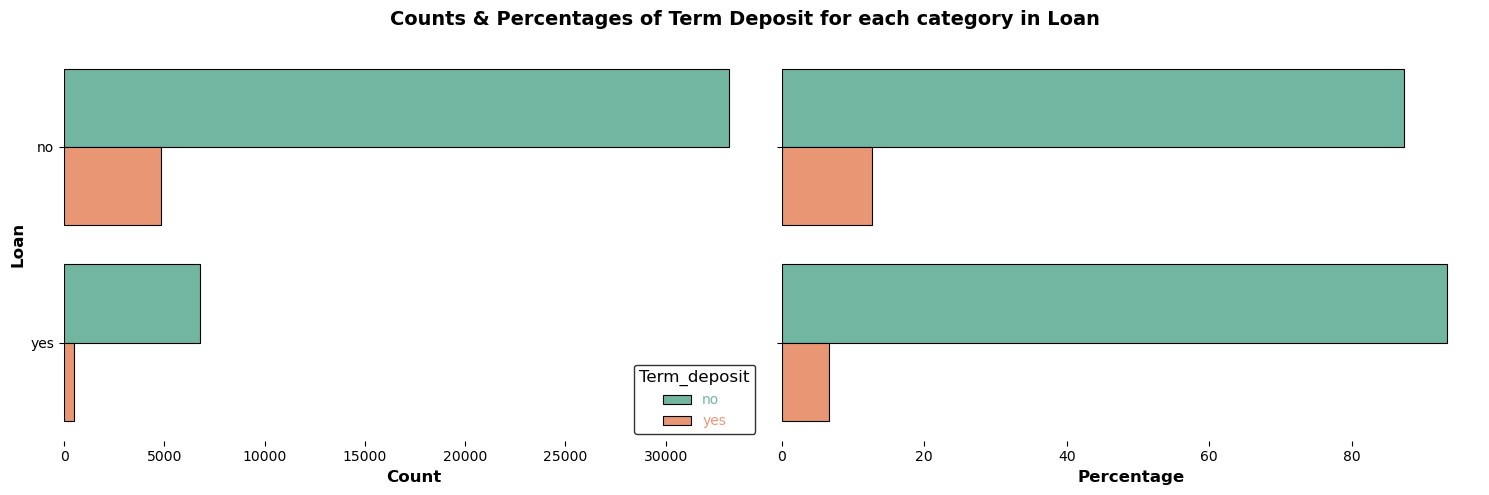

In [214]:
plot_categorical_columns(data, column='loan')

**Campaign**

**How the percentage of subscribers of term deposits varies with the campaign attempts**

In [215]:
data['campaign'].value_counts()[:5]

campaign
1    17544
2    12505
3     5521
4     3522
5     1764
Name: count, dtype: int64

In [216]:
data['campaign'].describe()

count   45211.00
mean        2.76
std         3.10
min         1.00
25%         1.00
50%         2.00
75%         3.00
max        63.00
Name: campaign, dtype: float64

term_deposit,no,yes,pct_success
campaign,,,
1,14983,2561,14.60
2,11104,1401,11.20
3,4903,618,11.19
4,3205,317,9.00
5,1625,139,7.88
6,1199,92,7.13
7,688,47,6.39
8,508,32,5.93
9,306,21,6.42


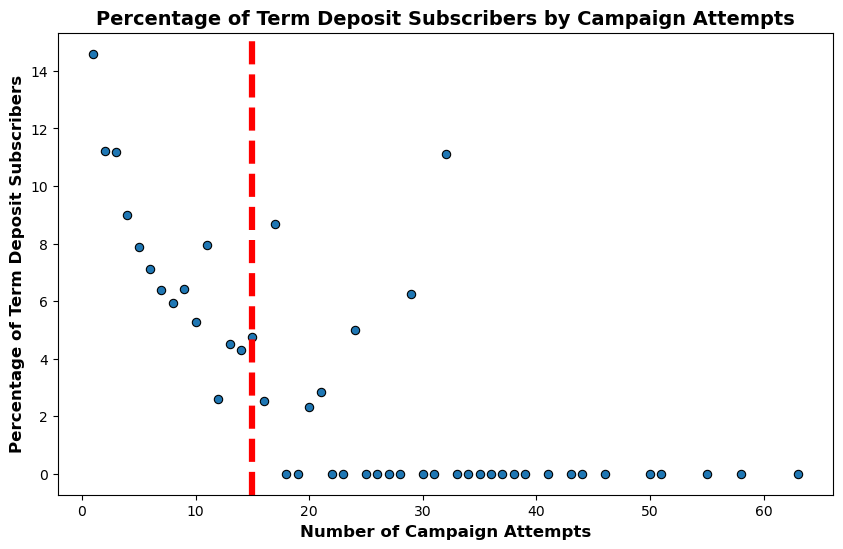

In [217]:
campaign_counts = pd.crosstab(data['campaign'], data['term_deposit'])
campaign_counts['pct_success'] = ((campaign_counts['yes']/(campaign_counts['no'] + campaign_counts['yes'])))*100
display(campaign_counts.head(10))

# plot scatter plot for campaign attempts and percentage of term deposit subscribers
plt.figure(figsize=(10,6))
sns.scatterplot(data=campaign_counts, x='campaign', y='pct_success', palette='Set2', edgecolor='black', linewidth=0.8)
plt.axvline(x=15, color='red', linestyle='--', linewidth=4.5)
plt.xlabel('Number of Campaign Attempts', fontsize=12, fontweight='bold')
plt.ylabel('Percentage of Term Deposit Subscribers', fontsize=12, fontweight='bold')
plt.title('Percentage of Term Deposit Subscribers by Campaign Attempts', fontsize=14, fontweight='bold')
plt.show()

**Insight**

- Analysis shows that when the number of campaign contacts exceeds 10, the likelihood of converting customers to term deposits drops significantly. In other words, attempts beyond 10 are rarely effective.

**Pdays**

In [218]:
data['pdays'].value_counts()[:5]

pdays
-1      36954
 182      167
 92       147
 91       126
 183      126
Name: count, dtype: int64

In [219]:
pday_df = pd.crosstab(data['pdays'], data['term_deposit'])
pday_df['pct_success'] = ((pday_df['yes']/(pday_df['no'] + pday_df['yes'])))*100
display(pday_df[:10].style.bar(subset='pct_success'))

term_deposit,no,yes,pct_success
pdays,,,
-1,33570,3384,9.157331
1,9,6,40.000000
2,35,2,5.405405
3,1,0,0.000000
4,1,1,50.000000
5,11,0,0.000000
6,9,1,10.000000
7,7,0,0.000000
8,25,0,0.000000


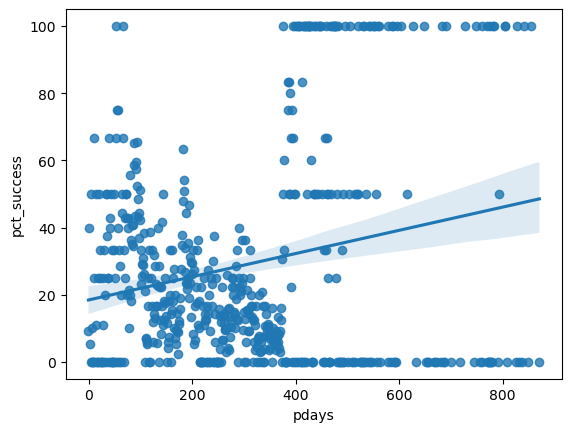

In [220]:
sns.regplot(pday_df, x=pday_df.index, y='pct_success');

**Insight :**

- This campaign primarily targeted new customers. The analysis indicates that clients who had not been contacted previously are the least likely to subscribe to a term deposit.

**Previous**

In [221]:
data['previous'].value_counts()[:5]

previous
0    36954
1     2772
2     2106
3     1142
4      714
Name: count, dtype: int64

In [222]:
prv_df = pd.crosstab(data['previous'], data['term_deposit'])
prv_df['pct_success'] = ((prv_df['yes']/(prv_df['no'] + prv_df['yes'])))*100
display(prv_df[:10].style.bar(subset='pct_success'))


term_deposit,no,yes,pct_success
previous,,,
0,33570,3384,9.157331
1,2189,583,21.031746
2,1650,456,21.652422
3,848,294,25.744308
4,543,171,23.949580
5,338,121,26.361656
6,194,83,29.963899
7,151,54,26.341463
8,90,39,30.232558


**Insight**

- In this campaign, most of the customers contacted had no prior relationship with the bank. The analysis shows that these new customers are the least likely to subscribe to a term deposit.

#### **3.4. Which kind campaign bring more success?**

**Contact**

In [223]:
data['contact'].value_counts()

contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

,contact,term_deposit,count
0,cellular,no,24916
1,cellular,yes,4369
2,telephone,no,2516
3,telephone,yes,390
4,unknown,no,12490
5,unknown,yes,530


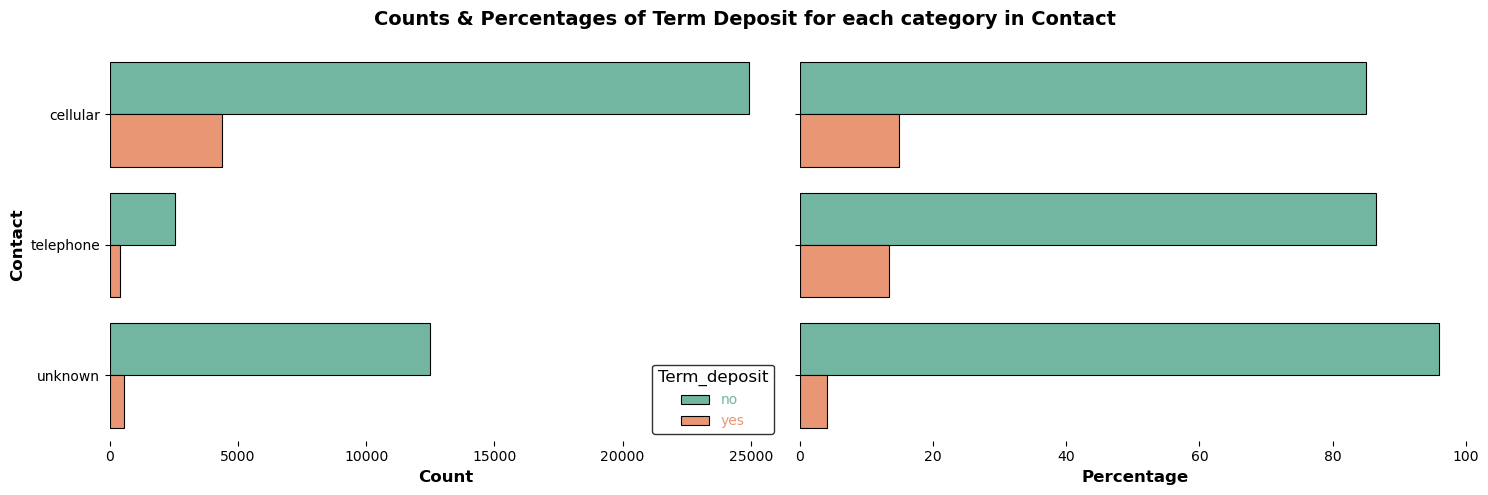

In [224]:
plot_categorical_columns(data, column='contact')

**Insight**

- The analysis indicates that cellular marketing campaigns generate more term deposit subscriptions compared to telephone campaigns.

#### **3.5. Seasonal Features**

**Number of subscribers of term deposit by month and day of week**

**Conclusion:**
By the below analysis, we conclude that:

- Most number of customers who subscribed to term deposits in month of May and in all day of week except for thursday. 

- Least number of customers who subscribed to term deposits in month of December and in all day of week. Holidays and festive seasons are not effective in converting customers to term deposits.

In [225]:
months_arr = [
    [i, m]
    for i, m in enumerate(data['month'])
    if i==0 or m != data['month'].iloc[i-1]    ## "Take this row if it's the first row OR if the month changed compared to the previous row."
]
months_arr = np.array(months_arr)


**We've got :**

**2008 : [0, 27729)**

**2009 : [27729, 42591)**

**2010 : [42591, shape of data)**



In [226]:
data.shape

(45211, 17)

In [227]:
## create year feature

data['year'] = np.hstack((np.array([2008] * (27729 - 0)),
           np.array([2009] * (42591 - 27729)),
           np.array([2010] * (45211 - 42591))))

month,apr,aug,dec,feb,jan,jul,jun,mar,may,nov,oct,sep
day,,,,,,,,,,,,
1,13,0,0,3,0,10,39,0,0,0,6,19
2,6,6,4,38,0,25,59,25,0,5,2,12
3,5,12,8,42,0,15,49,20,0,16,0,11
4,0,38,8,45,0,4,48,8,66,3,0,10
5,12,55,0,33,0,2,55,21,32,5,0,0
6,15,46,0,16,0,8,17,5,43,6,14,11
7,6,41,7,0,1,38,1,0,44,0,4,15
8,28,21,0,10,2,44,12,8,34,6,12,24
9,13,2,11,27,0,25,26,18,12,17,2,26


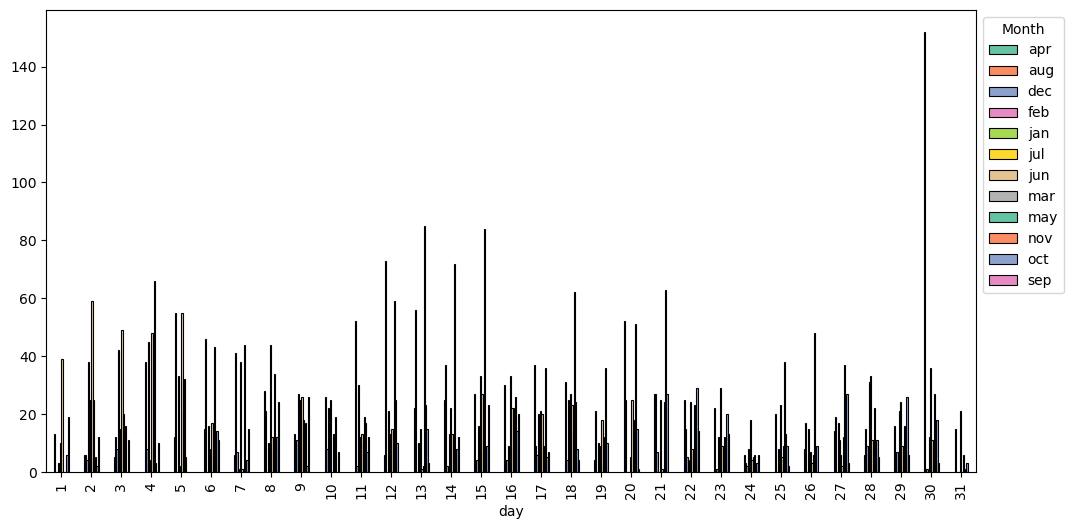

In [134]:
data1 = data[(data['term_deposit']=='yes')]
subsciber_df = pd.crosstab(data1['day'], data1['month'])
display(subsciber_df.style.highlight_max(axis='columns',color='yellow').highlight_min(axis='columns',color='coral'))


g = subsciber_df.plot(kind='bar',stacked=False,figsize=(12,6), color=sns.color_palette("Set2", n_colors=12), edgecolor='black', linewidth=0.8)
g.legend(title='Month',bbox_to_anchor=(1,1))
plt.show()

## **4. Bivariate Analysis**

**4.1. Numerical-Numerical**

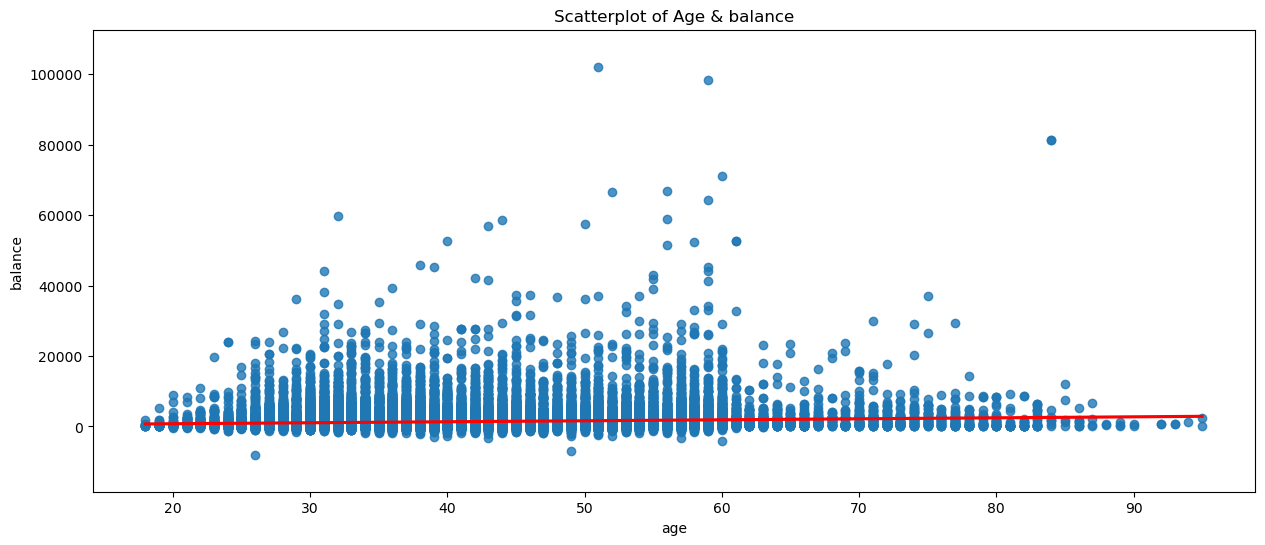

In [135]:
fig, ax = plt.subplots(figsize=(15, 6))
sns.regplot(data=data, x='age', y='balance', line_kws={"color":"red"}, ax=ax)

bottom, top = ax.get_ylim()
ax.set_ylim(bottom-5000, top + 5000)
ax.set_title("Scatterplot of Age & balance")

plt.show()

**Insight :**

- The dataset likely has balances centered around zero (many negative and positive values).

- balance is independent of age in this linear fit.


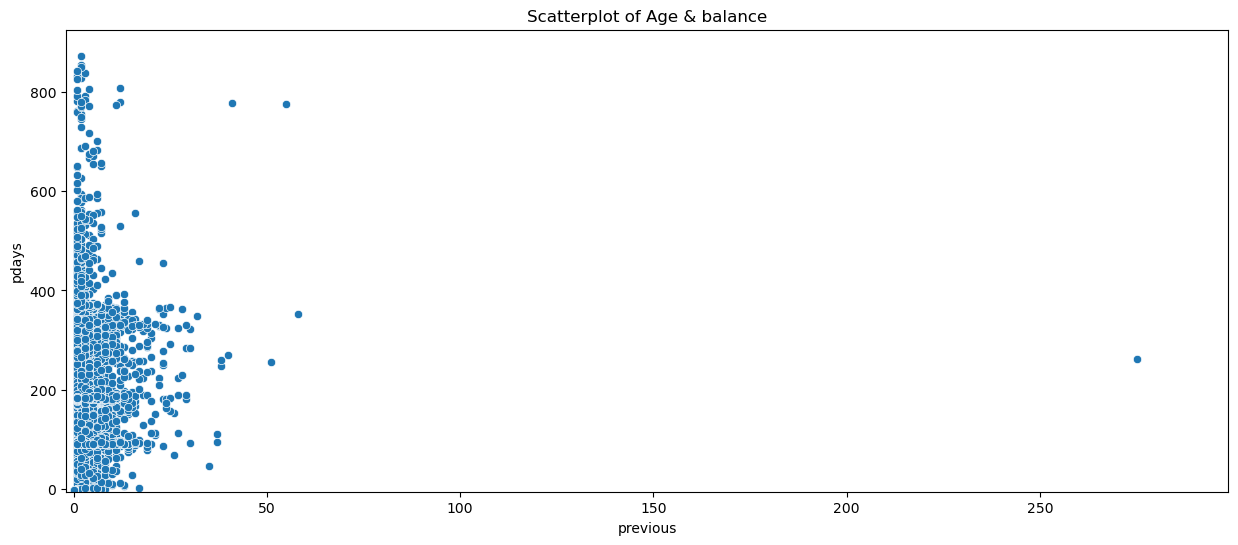

In [136]:
fig, ax = plt.subplots(figsize=(15, 6))
sns.scatterplot(data=data, x='previous', y='pdays', ax=ax)

bottom, top = ax.get_ylim()
ax.set_ylim(-5, top + 10)
ax.set_xlim(-2, ax.get_xlim()[1]+10)
ax.set_title("Scatterplot of Age & balance")

plt.show()

## **5. Multivariate analysis**

## **6. Outliers Analysis & Treatment**

In [137]:
# since duration = 0 doesn't have predictive power, we can drop it
new_df = data.query('duration > 0').reset_index(drop=True)
new_df.shape

(45208, 17)

In [138]:
print(f"Duplicate rows : {new_df.duplicated().sum()}", end="\n\n")
display(new_df.stb.missing().query('percent > 0'))

Duplicate rows : 0



,missing,total,percent


In [139]:
# plot outliers for numeric columns
def inspect_outliers(df:pd.DataFrame):
    # store numeric columns 
    numeric_col = df.select_dtypes(include=['number']).columns
    # iterate through each numeric column
    for col in numeric_col:
        fig, ax = plt.subplots(ncols=2, figsize=(15, 5))
        sns.boxplot(data=df, x = col, ax=ax[0], fill=False, color='k', flierprops=dict(marker='o', markerfacecolor='r'))
        sns.histplot(data=df, x = col, ax=ax[1], kde=False, color='lightblue')
        plt.suptitle(f'Outliers Analysis for {col.capitalize()}', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

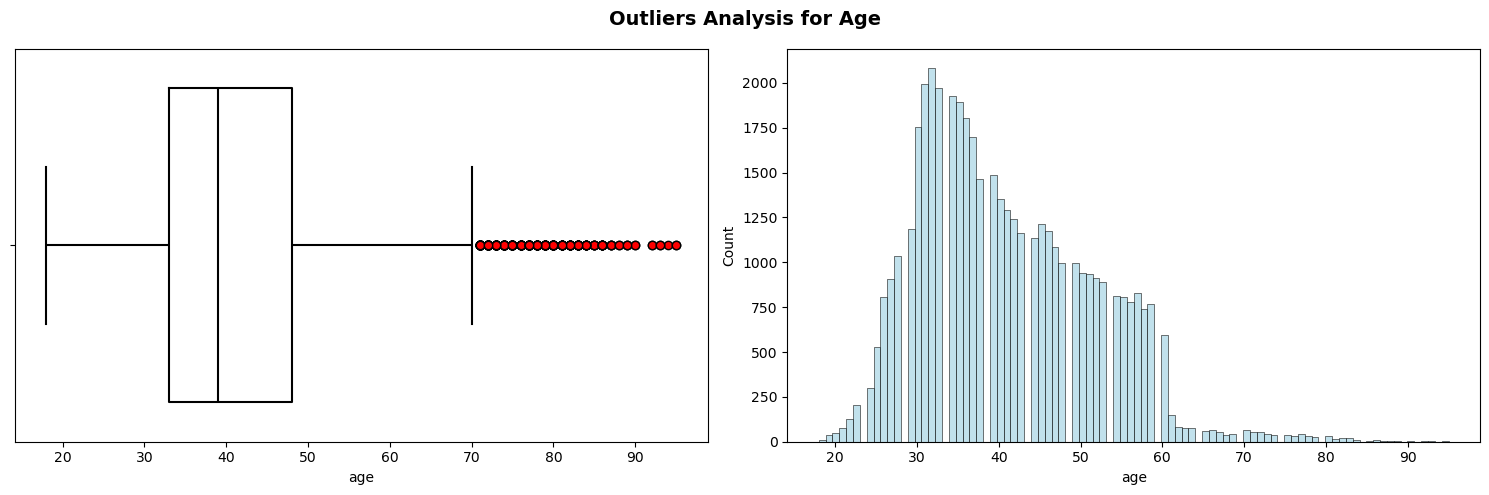

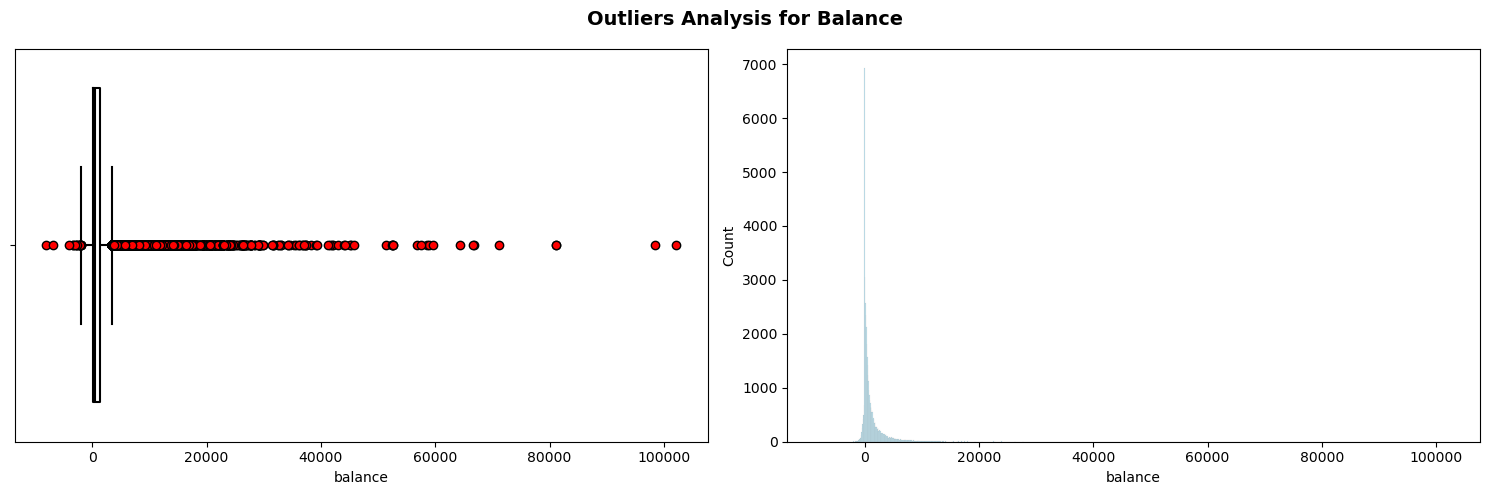

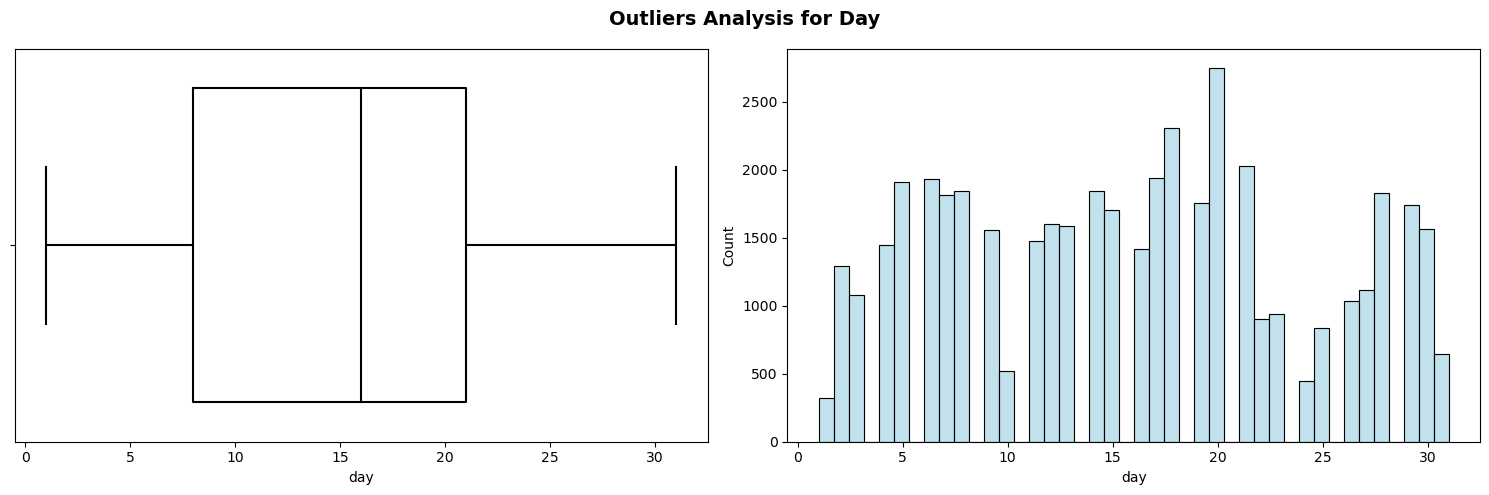

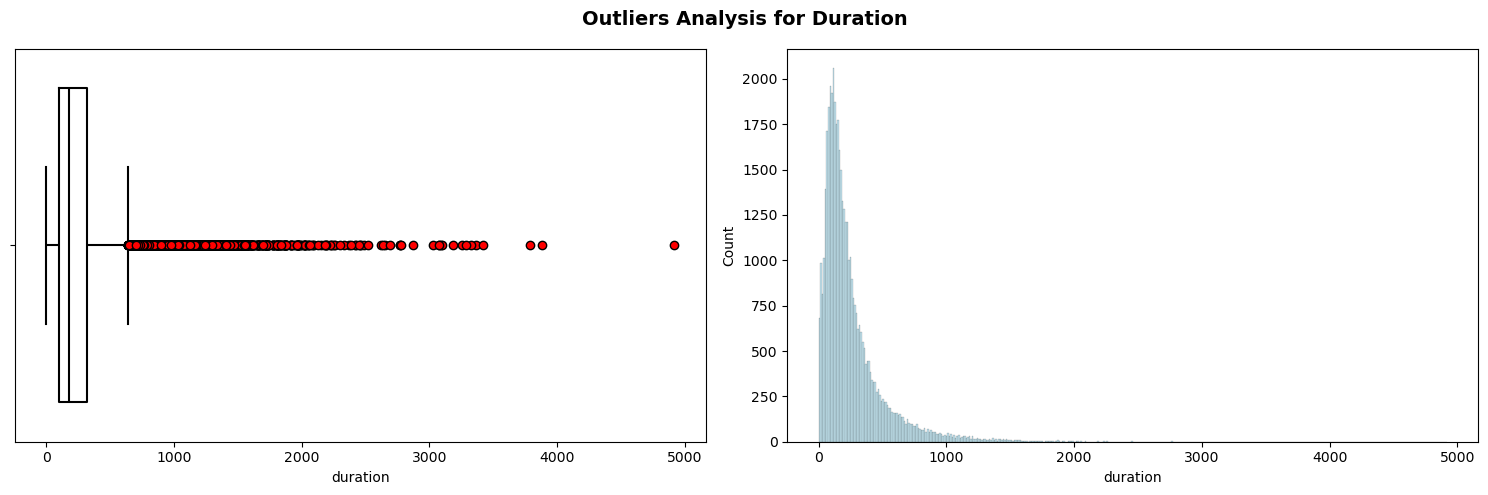

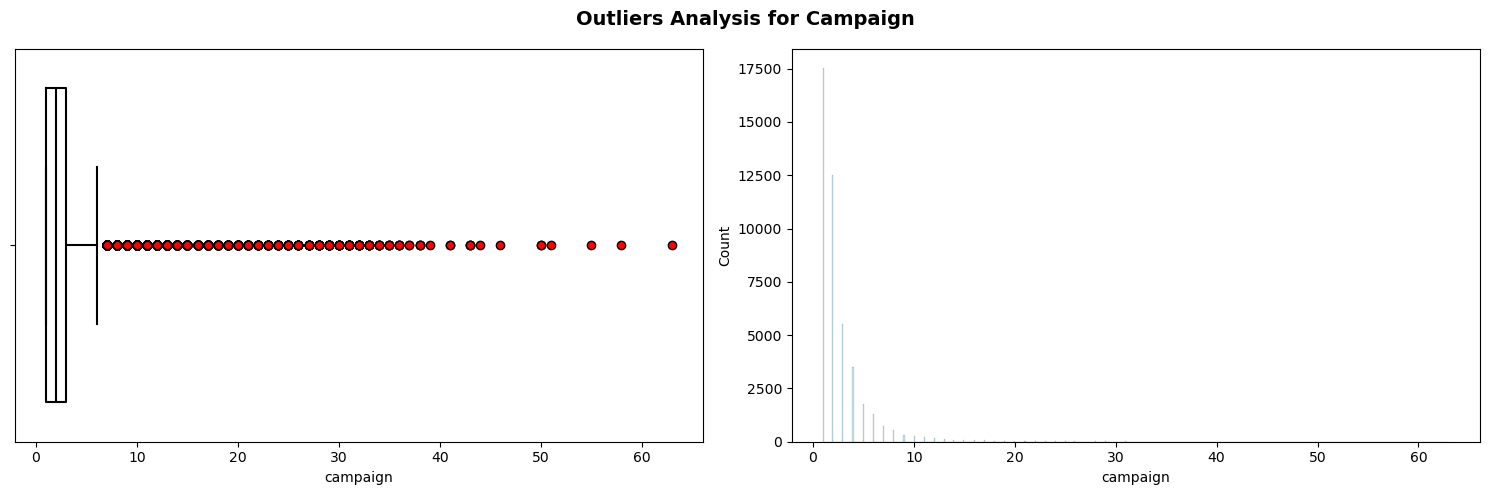

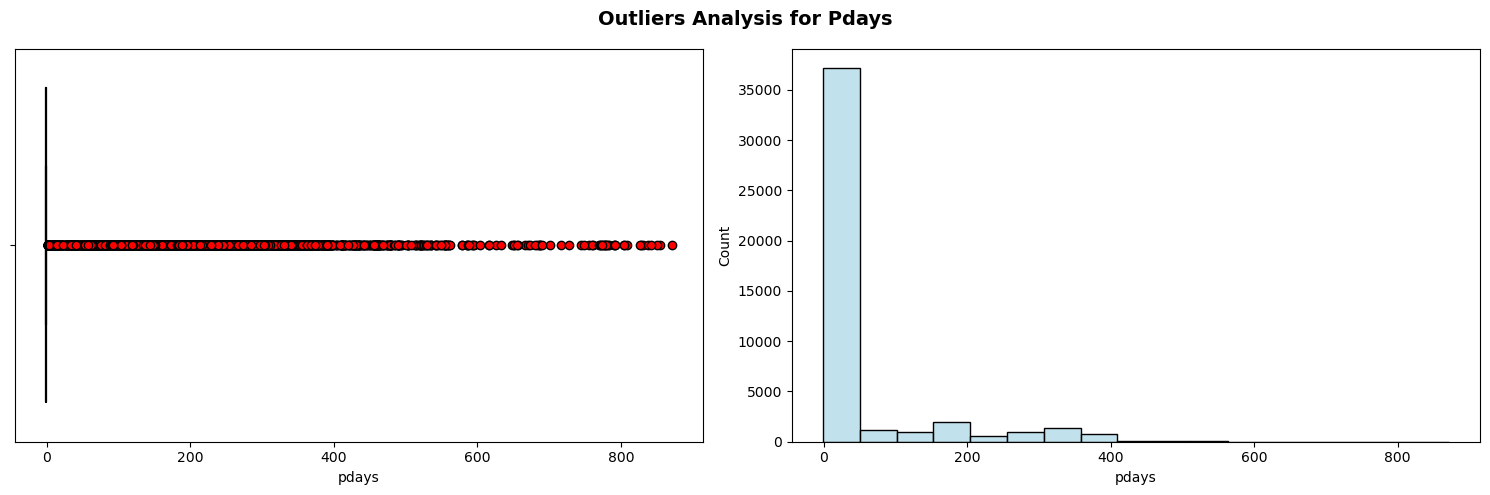

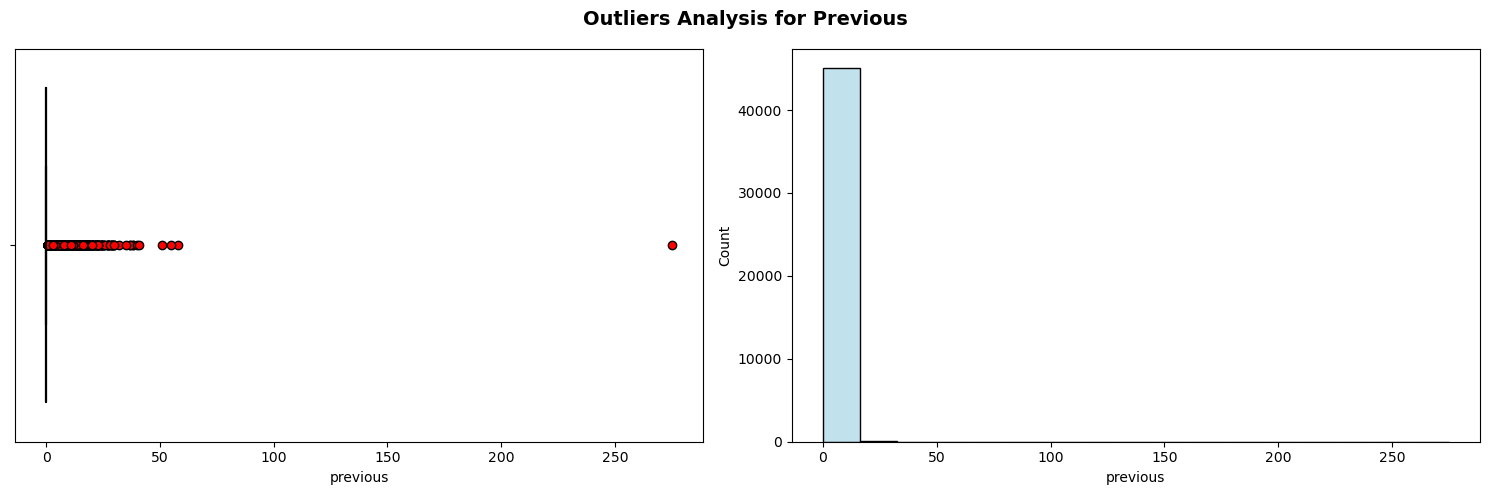

In [140]:
inspect_outliers(new_df)

In [141]:
# outliers percentage in each features
def calculate_outlier_percentage(df:pd.DataFrame, lower_percentile:float=5, upper_percentile: float=95) -> pd.DataFrame:
    """
    Calculate the percentage of outliers based on winsorized method for all the numeric columns in the DataFrame.

    Parameters:
    df(pd.DataFrame): The input DataFrame containing numerical features.
    lower_percentile(float): The lower percentile foe winsorization. Default is 5.
    upper_percentile(float): The upper percentile for winsorization. Default is 95.


    Returns:
    pd.DataFrame: A DataFrame contains features name along w.r.t their outlier percentage in it.
    """
    num_col = new_df.select_dtypes(include='number').columns
    variable = []
    outlier = []

    for col in num_col:
        x_low, x_high = np.percentile(new_df[col], [lower_percentile, upper_percentile])
        total = len(new_df[col])
        outliers_len = len(df[~df[col].between(x_low, x_high)])
        outlier_percentage = round((outliers_len/total)*100, 2)
        variable.append(col)
        outlier.append(outlier_percentage)

    outlier_df = pd.DataFrame(zip(variable, outlier), columns=['Features', 'Outliers Percentage'])
    return outlier_df

In [142]:
anamoly_df = calculate_outlier_percentage(new_df, lower_percentile=1, upper_percentile=99)
anamoly_df.sort_values(by=['Outliers Percentage'],ascending=False).reset_index(drop=True)

,Features,Outliers Percentage
0,balance,2.00
1,duration,1.92
2,age,1.63
3,campaign,1.00
4,previous,1.00
5,pdays,0.85
6,day,0.71


In [143]:
# Outlier Treatment using winsorization method 
def outlier_by_wisorize(df: pd.DataFrame, lower_percent:float=5, upper_percent:float=95, exclude_col:list=None)->pd.DataFrame:
    """
    A DataFrame with numeric columns in it.
    
    Parameters:
    df: the input DataFrame
    lower_percent: float value which by default take 5.
    upper_percent: float value which by default take 95.

    Return:
    A DataFrame without outliers.
    """
    df_winsorize = df.copy()
    num_col = df.select_dtypes(include='number').columns
    winsorize_col = set(num_col) - set(exclude_col) if exclude_col else num_col
    
    for col in winsorize_col:
        x_low, x_high = np.percentile(df[col],[lower_percent, upper_percent])
        df_winsorize[col] = np.where(df_winsorize[col] < x_low, x_low, df_winsorize[col]) # lower capping
        df_winsorize[col] = np.where(df_winsorize[col] > x_high, x_high, df_winsorize[col]) # upper capping

    return df_winsorize


In [144]:
winsorize_df = outlier_by_wisorize(new_df, lower_percent=1, upper_percent=99, exclude_col=['pdays'])

In [145]:
# check statistical difference or not of outlier capping on numeric columns
def plot_kde_before_after(df:pd.DataFrame, winsorize_df:pd.DataFrame, exclude_col:list):
    """
    Plot KDE for all numeric columns before and after winsorization and calculate wilcoxon rank-sum test results.

    Parameters:
    df: pd.DataFrame the original dataframe
    winsorize_df: winsorize method dataframe
    exclude_col: List of column to exclude from plotting
    """
    num_col = df.select_dtypes(include='number').columns
    plot_col = set(num_col) - set(exclude_col) if exclude_col else num_col

    #plot kdeplot
    for col in plot_col:
        fig, ax = plt.subplots(1,1, figsize=(8,4))
        sns.kdeplot(df[col], ax=ax, label='Original', fill=True)
        sns.kdeplot(winsorize_df[col], ax=ax, label='Winsorized', fill=True)
        plt.title(f"KDE Plot for {col.capitalize()}", fontweight='bold')
        plt.xlabel(f"{col.capitalize()}", fontweight='bold')
        plt.ylabel('Density', fontweight='bold')
        plt.legend(labelcolor='linecolor')

        plt.tight_layout()
        plt.show()
        # Wilcoxon rank-sum test
        u_stats, p_value = stats.mannwhitneyu(df[col], winsorize_df[col])
        print(f"Wilcoxon rank-sum test for '{col}' : U Statistic: {u_stats:.4f}, P-Value: {p_value:.4f}")
        if p_value < 0.05:
            print(f"The Distributions of '{col}' are statistically different (p_value < 0.05).")
        else:
            print(f"The Distributions of '{col}' are not statistically different (p_value > 0.05).")

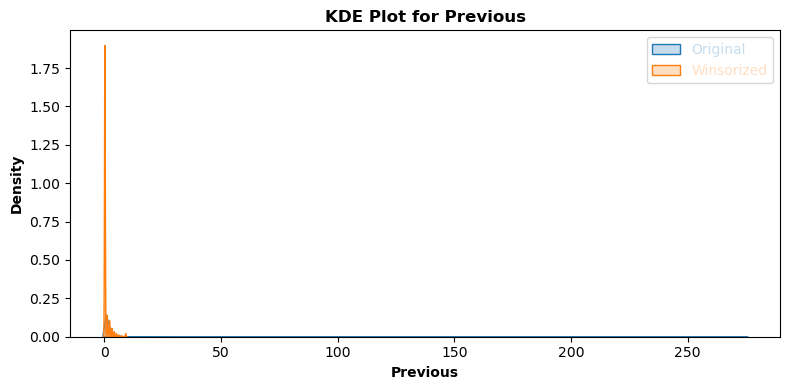

Wilcoxon rank-sum test for 'previous' : U Statistic: 1021984236.5000, P-Value: 0.9690
The Distributions of 'previous' are not statistically different (p_value > 0.05).


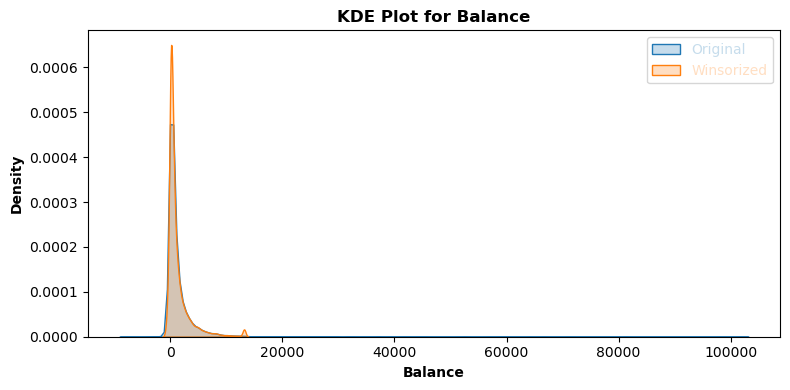

Wilcoxon rank-sum test for 'balance' : U Statistic: 1021882086.5000, P-Value: 0.9999
The Distributions of 'balance' are not statistically different (p_value > 0.05).


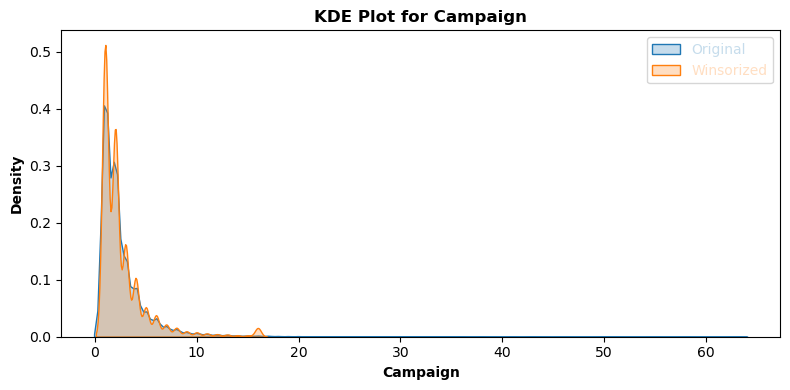

Wilcoxon rank-sum test for 'campaign' : U Statistic: 1022001147.0000, P-Value: 0.9746
The Distributions of 'campaign' are not statistically different (p_value > 0.05).


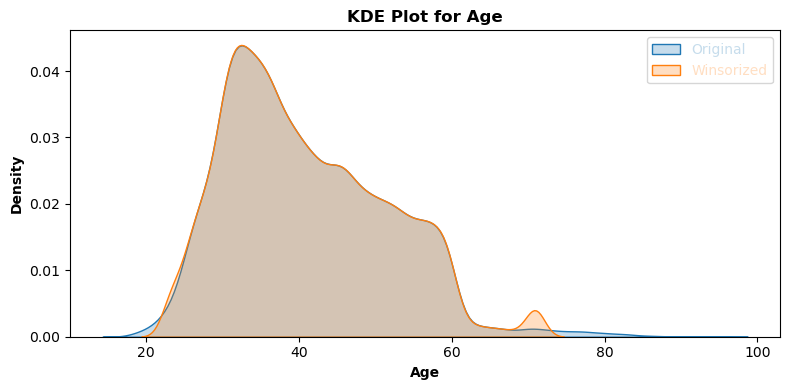

Wilcoxon rank-sum test for 'age' : U Statistic: 1021909750.0000, P-Value: 0.9943
The Distributions of 'age' are not statistically different (p_value > 0.05).


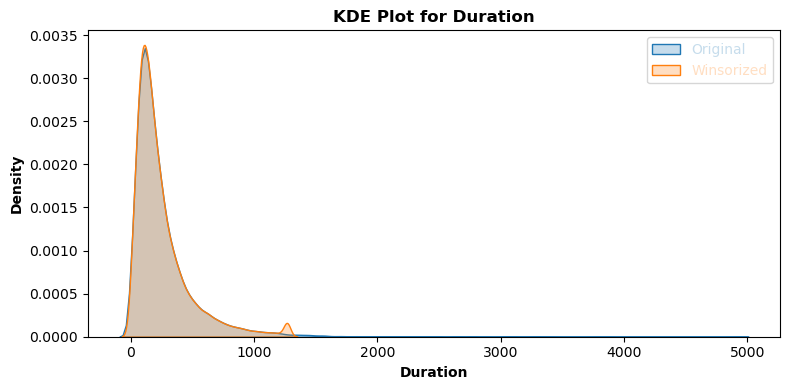

Wilcoxon rank-sum test for 'duration' : U Statistic: 1021877996.0000, P-Value: 0.9993
The Distributions of 'duration' are not statistically different (p_value > 0.05).


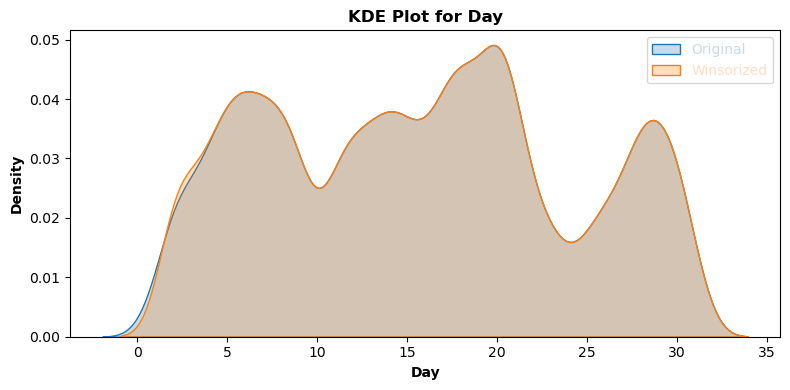

Wilcoxon rank-sum test for 'day' : U Statistic: 1021621617.0000, P-Value: 0.9471
The Distributions of 'day' are not statistically different (p_value > 0.05).


In [146]:
plot_kde_before_after(new_df, winsorize_df, exclude_col=['pdays'])

## **7. Feature Engineering**

In [147]:
winsorize_df['age_group'] = pd.cut(winsorize_df['age'],bins=3, labels=['young','middle-age','senior'])
winsorize_df.head(1)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,term_deposit,age_group
0,58.00,management,married,tertiary,no,2143.00,yes,no,unknown,5.00,may,261.00,1.00,-1,0.00,unknown,no,senior


#### **7.1. Feature Selection**

**Numerical Features**

**7.1.1Correlation Method**

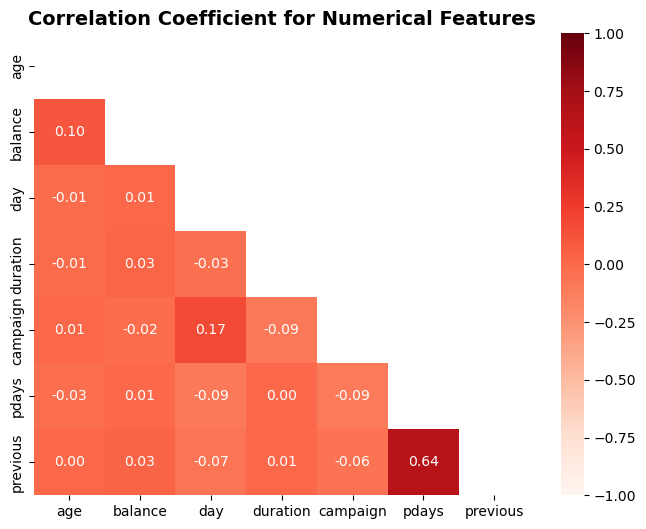

In [148]:
# Calculate correlation of numerical columns
corr_df = winsorize_df.select_dtypes(include='number').corr()

# Generate a mask for upper triangle
mask = np.zeros_like(corr_df, dtype=bool)
mask[np.triu_indices_from(mask)] = True
# plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_df, annot=True, fmt='.2f', mask=mask, cmap='Reds',vmin=-1, vmax=1, cbar=True)
plt.title('Correlation Coefficient for Numerical Features',fontsize=14, fontweight='bold')
plt.show()

**pearson's r also known as Pearson Correlation Coefficient. It calculates linear relation between numerical features. Eliminating Features on this basis would only runs the risk of removing too much information, which is detrimental to your efforts for building a reliable model. Follow hybrid method for elimination of features, will use VIF.**

**7.1.2. VIF Method**

In [149]:
# compute vif for numeric columns
def calculate_vif(df:pd.DataFrame):

    #select numeric columns
    num_df = df.select_dtypes(include='number')
    # the computation of vif required constant
    num_df['intercept'] = 1

    # create Dataframe to store features and vif values
    vif_df = pd.DataFrame()
    vif_df['Features'] = num_df.columns
    vif_df['VIF'] = [variance_inflation_factor(num_df.values, i) for i in range(num_df.shape[1])]
    vif_df = vif_df[vif_df['Features'] != 'intercept']
    return(vif_df)

# Criterion: Remove variable with vif >= 5

In [150]:
vif = calculate_vif(winsorize_df)
vif['VIF'] = vif['VIF'].round(0)
vif

,Features,VIF
0,age,1.00
1,balance,1.00
2,day,1.00
3,duration,1.00
4,campaign,1.00
5,pdays,2.00
6,previous,2.00


In [151]:
vif[vif['VIF']>4]['Features'].to_list()

[]

**7.1.3. Skewness of Numeric Features**

previous   3.66
balance    3.07
campaign   2.87
pdays      2.62
duration   2.08
age        0.55
day        0.10
dtype: float64


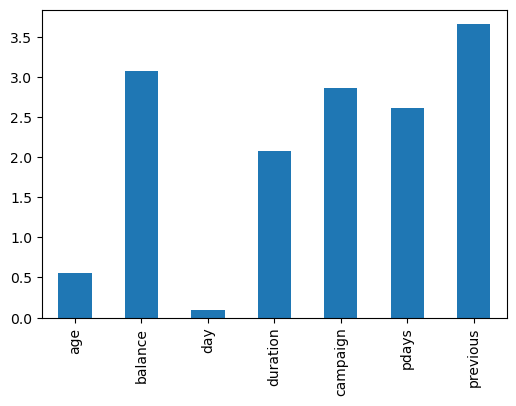

In [152]:
"""
Zero means normally distributed feature i.e., bell shaped curve.
Positive value means feature has rightly-skewed distribution.
Negative value means feature has left-skewed distribution.

"""
skewed = winsorize_df.select_dtypes(include='number').apply(lambda x: stats.skew(x))
print(skewed.sort_values(ascending=False))

# plot skewness of each features
ax=skewed.plot(kind='bar',figsize=(6,4))
plt.show()


**Categorical Features**

*****Categorical Features Modification*****

- **If three categories and one is sparse, impute with max frequency. If more than three categories and some are sparse, mold sparses into 'other' categories.**

In [153]:
winsorize_df['marital'].value_counts(normalize=True).idxmax() == winsorize_df['marital'].mode()

0    True
Name: marital, dtype: bool

In [154]:
def replace_small_categories_with_mode(df:pd.DataFrame, column:str):
    """
    A Dataframe with categorical columns in it.

    Parameters:
    df(pd.DataFrame): the input dataframe.
    column(str): list of columns to replace smallest category with mode / maximum value

    Returns:
    pd.DataFrame: A DataFrame with categorical columns whose smallest category is replaced.
    
    """
    # Lets make a df copy 
    df_copy = df.copy(deep=True)

    # calculate proportions of each columns
    category_proportions = df_copy[column].value_counts(normalize=True)

    # Identify the category with smallest proportions
    small_category = category_proportions.idxmin()

    # Find most frequent category
    mode = category_proportions.idxmax()
 
    # Replace small category with mode if number of categories is equal to 3
    if len(category_proportions)==3:
        df_copy[column] = np.where(df_copy[column]==small_category, mode, df_copy[column])
    
    return df_copy

In [155]:
cat_col = winsorize_df.select_dtypes(exclude='number').columns
col = [col for col in cat_col if 'unknown' in winsorize_df[col].values]
for i in col:
    print(i  , (winsorize_df[i].nunique()))

job 12
education 4
contact 3
poutcome 4


In [156]:
# mutate for categorical column where it has three categories

mutate_with_mode = ['default', 'housing', 'loan']
for col in mutate_with_mode:
    winsorize_df = replace_small_categories_with_mode(winsorize_df, column= col)

In [157]:
def merge_small_categories(df:pd.DataFrame, column:str, threshold: float, min_categories=4, categories_under_threshold=1):
    """
    
    """
    # Let's create a copy 
    df_copy = df.copy(deep=True)

    # Calculate the proportion of each category
    category_proportions = df_copy[column].value_counts(normalize=True)

    # Identify small categories
    small_category = category_proportions[category_proportions < threshold].index

    # Check if the total number of unique categories is greater than the specified categories
    if len(category_proportions) >= min_categories:
        # Check if at least the specified number of categories greater than number of threshold category
        if len(small_category) >= categories_under_threshold:
            #Replace small categories with 'Others' using map
            df_copy[column] = df_copy[column].map(lambda x: 'Others' if x in small_category else x)
    
    return df_copy

In [158]:
merge_threshold = {'job': 0.03, 'marital': 0.01, 'education': 0.05}

for col, threshold in merge_threshold.items():
    winsorize_df = merge_small_categories(winsorize_df, column=col, threshold=threshold)

In [159]:
# Mapping dictionaries(use Q2, Q3 and write Q1, Q4 as 'others')
month_to_quarter = {'jan': 'Others', 'feb': 'Others', 'mar': 'Others',
                    'apr': 'Q2', 'may': 'Q2', 'jun': 'Q2',
                    'jul': 'Q3', 'aug': 'Q3', 'sep': 'Q3',
                    'oct': 'Others', 'nov': 'Others', 'dec': 'Others'}

winsorize_df['quarter'] = winsorize_df['month'].map(month_to_quarter)

**5.1.4. Cramer's V**

**Cramer's V unlocks the strength and direction of associations between categorical features and returns a value between 0(weak) and 1(strong).**

In [160]:
def cramers_v(x,y):
    """ Calculate Cramers'V statistics for two categorical variables."""
    confusion_matrix = pd.crosstab(x,y) # compute contigency table
    chi2, p, dof, expected = stats.chi2_contingency(confusion_matrix) # compute chi2 statistics
    n = confusion_matrix.sum().sum() # total number of observations
    min_dim = min(confusion_matrix.shape) - 1 # minimum dimension of confusion matix
    V = np.sqrt((chi2 / n) / min_dim) # calculate cramers'V statistics
    return V, chi2, p, dof



def filter_cat_features_association(df:pd.DataFrame):
    """
    Calculate cramers'V and chi-squared for each pair of categorical features.

    Parameters:
    df(pd.DataFrame): The input dataframe contains categorical features.

    Returns: 
    pd.DataFrame: A DataFrame contiaing pair of categorical features with their cramers'v values, chi-squared statistics, p_value, degree of freedom.
    """

    cat_col = df.select_dtypes(exclude='number').columns
    results = []

    for col1, col2 in combinations(cat_col, 2):
        V, chi2, p, dof = cramers_v(df[col1], df[col2])
        results.append({'Feature1': col1, 'Feature2': col2, 'Cramers_V': V, 'P_value': p, 'Degrees of Freedom': dof})

    results_df = pd.DataFrame(results)
    return results_df



In [161]:
pd.set_option('display.max_rows' ,None)
# Association between columns other than target_column: term_deposit
cramers_df = filter_cat_features_association(winsorize_df)
cramers_df[(cramers_df['Feature2'] != 'term_deposit') & (cramers_df['Feature1'] != 'term_deposit')].reset_index(drop=True)

,Feature1,Feature2,Cramers_V,P_value,Degrees of Freedom
0,job,marital,0.15,0.00,16
1,job,education,0.44,0.00,24
2,job,default,0.03,0.00,8
3,job,housing,0.28,0.00,8
4,job,loan,0.10,0.00,8
5,job,contact,0.15,0.00,16
6,job,month,0.12,0.00,88
7,job,poutcome,0.05,0.00,24
8,job,age_group,0.37,0.00,16
9,job,quarter,0.16,0.00,16


In [162]:
# Association between columns and target column: term_deposit
cramers_df[(cramers_df['Feature2'] == 'term_deposit') | (cramers_df['Feature1'] == 'term_deposit')].reset_index(drop=True)

,Feature1,Feature2,Cramers_V,P_value,Degrees of Freedom
0,job,term_deposit,0.12,0.00,8
1,marital,term_deposit,0.07,0.00,2
2,education,term_deposit,0.07,0.00,3
3,default,term_deposit,0.02,0.00,1
4,housing,term_deposit,0.14,0.00,1
5,loan,term_deposit,0.07,0.00,1
6,contact,term_deposit,0.15,0.00,2
7,month,term_deposit,0.26,0.00,11
8,poutcome,term_deposit,0.31,0.00,3
9,term_deposit,age_group,0.09,0.00,2


In [163]:
def cramers_v(x,y):
    """ Calculate Cramers'V statistics for two categorical variables."""
    confusion_matrix = pd.crosstab(x,y) # compute contigency table
    chi2, p, dof, expected = stats.chi2_contingency(confusion_matrix) # compute chi2 statistics
    n = confusion_matrix.sum().sum() # total number of observations
    min_dim = min(confusion_matrix.shape) - 1 # minimum dimension of confusion matix
    V = np.sqrt((chi2 / n) / min_dim) # calculate cramers'V statistics
    return V



In [164]:


def filter_cat_features_visualization(df:pd.DataFrame):
    """
    Calculate cramers'V and chi-squared for each pair of categorical features.

    Parameters:
    df(pd.DataFrame): The input dataframe contains categorical features.

    Returns: 
    pd.DataFrame: A DataFrame contiaing pair of categorical features with their cramers'v values, chi-squared statistics, p_value, degree of freedom.
    """

    cat_col = df.select_dtypes(exclude='number').columns
    #results = []
    cramers_result = pd.DataFrame(index=cat_col.to_list(), columns=cat_col.to_list())
    #corrM = np.zeros((len(cat_col), len(cat_col)))

    #for col1, col2 in combinations(cat_col, 2):
    for col1 in cat_col:
        for col2 in cat_col:
            if col1 != col2:
                cramers_result.loc[col1, col2] = cramers_v(df[col1], df[col2])
            else:
                cramers_result.loc[col1, col2] = 1
    
    cramers_result = cramers_result.astype(float)
    return cramers_result



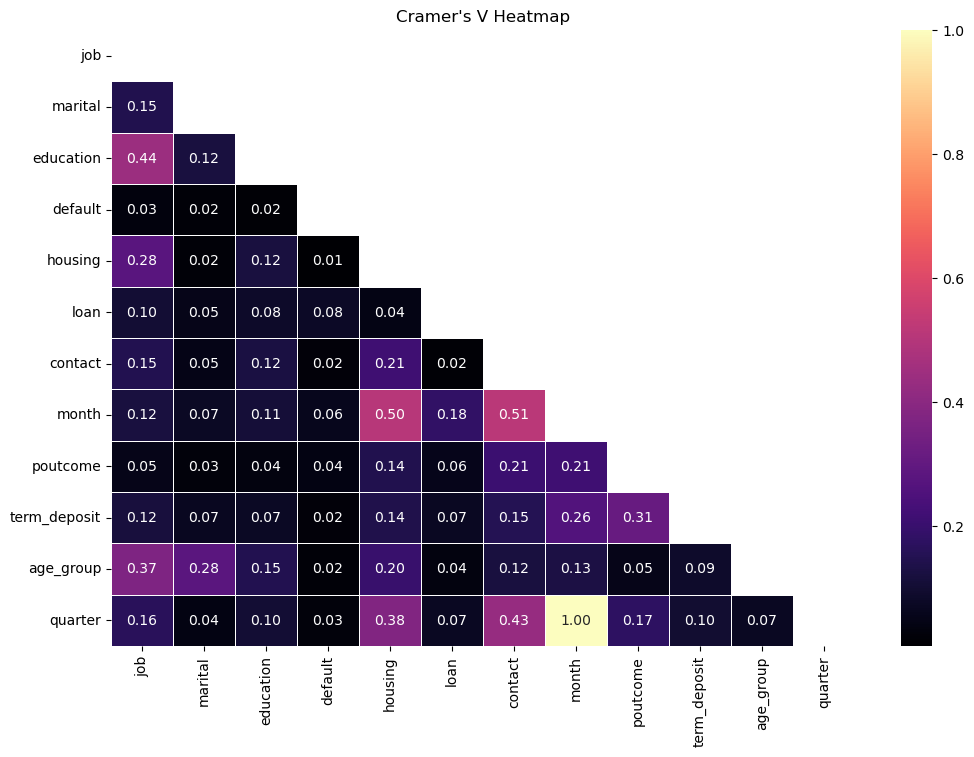

In [165]:
cramers_df = filter_cat_features_visualization(winsorize_df)
plt.figure(figsize=(12, 8))
mask = np.zeros_like(cramers_df, dtype='bool')
mask[np.triu_indices_from(mask)] = True
sns.heatmap(cramers_df, mask=mask ,annot=True, cmap='magma', fmt=".2f", linewidths=0.5)
plt.title("Cramer's V Heatmap")
plt.show()
